In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [4]:
glakes = gpd.read_file(r'model_data\Final data\lakes_imputed_22.gpkg')
glakes.columns
lakes_clean = glakes.copy()

In [5]:
drop_cols = [
    'area_1990', 'geometry_1990',
    'area_2000',  'geometry_2000',
    'area_2010', 'geometry_2010',
    'area_2015', 'geometry_2015',
    'area_2020', 'RGIId'
]

lakes_clean = glakes.drop(columns=drop_cols)
print(lakes_clean.columns.tolist())
print(lakes_clean.shape)

# Check nulls in your feature columns before modelling
print(lakes_clean.isnull().sum()[lakes_clean.isnull().sum() > 0])

['Type', 'Elevation', 'GLAKE_ID', 'perimeter_2020', 'perimeter_1990', 'perimeter_2000', 'perimeter_2010', 'perimeter_2015', 'area_1990_km2', 'area_2000_km2', 'area_2010_km2', 'area_2015_km2', 'area_2020_km2', 'expansion_rate_km2_yr', 'expansion_rate_pct_yr', 'glof_happened', 'glof_count', 'lake_type', 'distance_to_glacier_m', 'nearest_rgiid', 'is_connected', 'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility', 'volume_m3', 'max_depth_m', 'surface_elevation_m', 'area_m2', 'perimeter_m', 'G11_mean_slope_deg', 'area_exp_1990_2000', 'area_exp_pct_1990_2000', 'area_cagr_pct_1990_2000', 'area_exp_2000_2010', 'area_exp_pct_2000_2010', 'area_cagr_pct_2000_2010', 'area_exp_2010_2015', 'area_exp_pct_2010_2015', 'area_cagr_pct_2010_2015', 'area_exp_2015_2020', 'area_exp_pct_2015_2020', 'area_cagr_pct_2015_2020', 'area_exp_total', 'area_exp_total_pct', 'area_cagr_total_pct', 'n_expanding_intervals', 'n_shrinking_intervals', 'area_shrink_1990_2000', 'area_shrink_2000_2010', 'area_shrink_2010_2015

In [295]:
lakes_clean.columns

Index(['Type', 'Elevation', 'GLAKE_ID', 'perimeter_2020', 'perimeter_1990',
       'perimeter_2000', 'perimeter_2010', 'perimeter_2015', 'area_1990_km2',
       'area_2000_km2', 'area_2010_km2', 'area_2015_km2', 'area_2020_km2',
       'expansion_rate_km2_yr', 'expansion_rate_pct_yr', 'glof_happened',
       'glof_count', 'lake_type', 'distance_to_glacier_m', 'nearest_rgiid',
       'is_connected', 'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility',
       'volume_m3', 'max_depth_m', 'surface_elevation_m', 'area_m2',
       'perimeter_m', 'G11_mean_slope_deg', 'area_exp_1990_2000',
       'area_exp_pct_1990_2000', 'area_cagr_pct_1990_2000',
       'area_exp_2000_2010', 'area_exp_pct_2000_2010',
       'area_cagr_pct_2000_2010', 'area_exp_2010_2015',
       'area_exp_pct_2010_2015', 'area_cagr_pct_2010_2015',
       'area_exp_2015_2020', 'area_exp_pct_2015_2020',
       'area_cagr_pct_2015_2020', 'area_exp_total', 'area_exp_total_pct',
       'area_cagr_total_pct', 'n_expanding_inter

In [ ]:
# # Check rows with null expansion_rate_km2_yr and their glof values
expansion_null = lakes_clean[lakes_clean['expansion_rate_km2_yr'].isnull()]

print(f"Rows with null expansion_rate_km2_yr: {len(expansion_null)}")
print(f"\nOf these {len(expansion_null)} rows:")

# Check if they have values in glof_happened
glof_happened_notnull = expansion_null['glof_happened'].notna().sum()
print(f"  - Have non-null 'glof_happened': {glof_happened_notnull}")

# Check if they have values in glof_count
glof_count_notnull = expansion_null['glof_count'].notna().sum()
print(f"  - Have non-null 'glof_count': {glof_count_notnull}")

# Show the actual data for these rows
print("\nDetailed view:")
print(expansion_null[['expansion_rate_km2_yr', 'glof_happened', 'glof_count']])


Rows with null expansion_rate_km2_yr: 335

Of these 335 rows:
  - Have non-null 'glof_happened': 335
  - Have non-null 'glof_count': 335

Detailed view:
      expansion_rate_km2_yr  glof_happened  glof_count
28                      NaN              0           0
29                      NaN              0           0
30                      NaN              0           0
48                      NaN              0           0
51                      NaN              0           0
...                     ...            ...         ...
6900                    NaN              0           0
6904                    NaN              0           0
6905                    NaN              0           0
6914                    NaN              1          26
6915                    NaN              1           3

[335 rows x 3 columns]


In [5]:
lakes_clean['expansion_rate_missing'] = lakes_clean['expansion_rate_km2_yr'].isna().astype(int)
median_rate_km2 = lakes_clean['expansion_rate_km2_yr'].median()
median_rate_pct = lakes_clean['expansion_rate_pct_yr'].median()

lakes_clean['expansion_rate_km2_yr'] = lakes_clean['expansion_rate_km2_yr'].fillna(median_rate_km2)
lakes_clean['expansion_rate_pct_yr'] = lakes_clean['expansion_rate_pct_yr'].fillna(median_rate_pct)

In [6]:
lakes_clean['expansion_rate_km2_yr']

0      -0.001378
1       0.000379
2       0.003296
3       0.002807
4       0.004251
          ...   
6918    0.000103
6919    0.003108
6920    0.095593
6921    0.000509
6922    0.001707
Name: expansion_rate_km2_yr, Length: 6923, dtype: float64

In [17]:
import os

out_path = r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_clean.gpkg"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
lakes_clean.to_file(out_path, driver="GPKG")
print(f"Saved: {out_path}")

Saved: D:\Rubel\M.Tech\MTP\Phase 2\lakes_clean.gpkg


In [94]:
# lakes_clean = gpd.read_file(r'D:\Rubel\M.Tech\MTP\Phase 2\lakes_clean.gpkg')
lakes_clean.columns

Index(['Type', 'Elevation', 'GLAKE_ID', 'perimeter_2020', 'perimeter_1990',
       'perimeter_2000', 'perimeter_2010', 'perimeter_2015', 'area_1990_km2',
       'area_2000_km2', 'area_2010_km2', 'area_2015_km2', 'area_2020_km2',
       'expansion_rate_km2_yr', 'expansion_rate_pct_yr',
       'lake_type', 'distance_to_glacier_m', 'nearest_rgiid',
       'is_connected', 'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility',
       'volume_m3', 'max_depth_m', 'surface_elevation_m', 'area_m2',
       'perimeter_m', 'G11_mean_slope_deg', 'area_exp_1990_2000',
       'area_exp_pct_1990_2000', 'area_cagr_pct_1990_2000',
       'area_exp_2000_2010', 'area_exp_pct_2000_2010',
       'area_cagr_pct_2000_2010', 'area_exp_2010_2015',
       'area_exp_pct_2010_2015', 'area_cagr_pct_2010_2015',
       'area_exp_2015_2020', 'area_exp_pct_2015_2020',
       'area_cagr_pct_2015_2020', 'area_exp_total', 'area_exp_total_pct',
       'area_cagr_total_pct', 'n_expanding_intervals', 'n_shrinking_intervals',

# Random Forest


Lake type mapping: {'E(c)': np.int64(0), 'E(o)': np.int64(1), 'I(s)': np.int64(2), 'I(v)': np.int64(3), 'M(e)': np.int64(4), 'M(l)': np.int64(5), 'M(o)': np.int64(6), 'O': np.int64(7)}
Dropping non-numeric features: ['lake_type', 'nearest_rgiid', 'wse_m_dam', 'geometry']

Using 62 features
Class distribution -- GLOF: 42  No GLOF: 6880
Imbalance ratio: 1:163

Spatial blocks: 16 blocks
1       16
2     1330
3      980
4      342
6      550
7       57
8     1092
9      508
10       3
11     338
13       3
14      58
15     274
16     249
20    1077
21      45
Name: count, dtype: int64
Fold 1 -- AUC: 0.833  AP: 0.075  Recall(GLOF): 0.370
Fold 2 -- AUC: 0.786  AP: 0.036  Recall(GLOF): 0.267

-- CV Summary (RF + ADASYN) --
      roc_auc  avg_precision  threshold  precision_glof  recall_glof  f1_glof
mean    0.810          0.055      0.182           0.079        0.319    0.125
std     0.033          0.027      0.058           0.014        0.073    0.012

Overall OOF AP:   0.049
Overall OOF AU

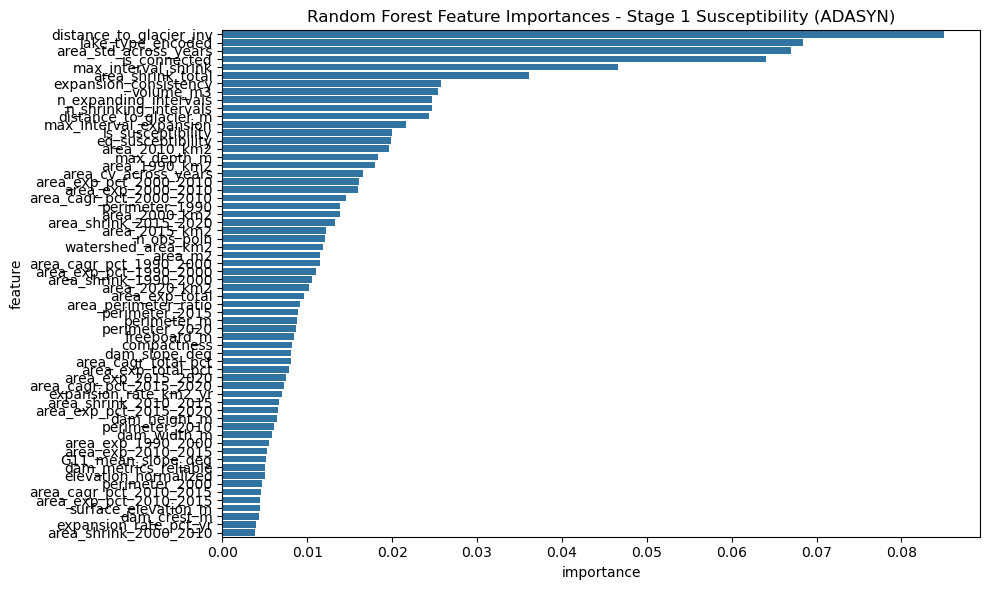


Done. RF + ADASYN outputs saved.


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from imblearn.over_sampling import ADASYN
except ImportError as e:
    raise ImportError(
        "ADASYN requires imbalanced-learn. Install with: pip install imbalanced-learn"
    ) from e

# -- 1. Load & prepare -------------------------------------------------------

# lakes = gpd.read_file(r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_clean.gpkg")
lakes = lakes_clean.copy()  # Use the cleaned version from previous steps

# Encode lake_type to numeric (keep original column untouched)
le = LabelEncoder()
lakes['lake_type_encoded'] = le.fit_transform(lakes['lake_type'].astype(str))
print("Lake type mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Inverse distance feature: nearby lakes get higher value
lakes['distance_to_glacier_inv'] = 1.0 / (1.0 + lakes['distance_to_glacier_m'].clip(lower=0))

# Candidate features (no target leakage, no raw string IDs)
candidate_feature_cols = [
    'perimeter_2020', 'perimeter_1990',
       'perimeter_2000', 'perimeter_2010', 'perimeter_2015', 'area_1990_km2',
       'area_2000_km2', 'area_2010_km2', 'area_2015_km2', 'area_2020_km2',
       'expansion_rate_km2_yr', 'expansion_rate_pct_yr',
     'distance_to_glacier_m',
       'is_connected', 'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility',
       'volume_m3', 'max_depth_m', 'surface_elevation_m', 'area_m2',
       'perimeter_m', 'G11_mean_slope_deg', 'area_exp_1990_2000',
       'area_exp_pct_1990_2000', 'area_cagr_pct_1990_2000',
       'area_exp_2000_2010', 'area_exp_pct_2000_2010',
       'area_cagr_pct_2000_2010', 'area_exp_2010_2015',
       'area_exp_pct_2010_2015', 'area_cagr_pct_2010_2015',
       'area_exp_2015_2020', 'area_exp_pct_2015_2020',
       'area_cagr_pct_2015_2020', 'area_exp_total', 'area_exp_total_pct',
       'area_cagr_total_pct', 'n_expanding_intervals', 'n_shrinking_intervals',
       'area_shrink_1990_2000', 'area_shrink_2000_2010',
       'area_shrink_2010_2015', 'area_shrink_2015_2020', 'area_shrink_total',
       'max_interval_expansion', 'max_interval_shrink', 'watershed_area_km2',
       'compactness', 'area_perimeter_ratio', 'elevation_normalized',
       'expansion_consistency', 'area_std_across_years',
       'area_cv_across_years', 'dam_crest_m', 'dam_height_m',
       'dam_metrics_reliable', 'dam_slope_deg', 'dam_width_m', 'freeboard_m',
       'n_obs_poin', 'geometry','lake_type_encoded','distance_to_glacier_inv'
]

available_feature_cols = [c for c in candidate_feature_cols if c in lakes.columns]
missing_feature_cols = [c for c in candidate_feature_cols if c not in lakes.columns]

if missing_feature_cols:
    print(f"Missing candidate features: {len(missing_feature_cols)}")
    print(missing_feature_cols)

# Ensure model matrix is numeric for ADASYN / RF
non_numeric_cols = [
    c for c in available_feature_cols
    if not pd.api.types.is_numeric_dtype(lakes[c])
]
if non_numeric_cols:
    print(f"Dropping non-numeric features: {non_numeric_cols}")

feature_cols = [c for c in available_feature_cols if c not in non_numeric_cols]

if len(feature_cols) == 0:
    raise ValueError("No usable numeric feature columns available for modeling.")

# Keep only rows with complete model inputs and target
# Replace inf from ratio/cagr features before dropna
lakes[feature_cols] = lakes[feature_cols].replace([np.inf, -np.inf], np.nan)
model_df = lakes.dropna(subset=feature_cols + ['glof_happened']).copy()

if len(model_df) == 0:
    raise ValueError("No rows left after filtering for non-missing features and target.")

X = model_df[feature_cols].values
y = model_df['glof_happened'].astype(int).values

n_pos = int(y.sum())
n_neg = int((y == 0).sum())
print(f"\nUsing {len(feature_cols)} features")
print(f"Class distribution -- GLOF: {n_pos}  No GLOF: {n_neg}")
if n_pos > 0:
    print(f"Imbalance ratio: 1:{max(1, n_neg // n_pos)}")
else:
    raise ValueError("No positive class rows found after filtering.")

# -- 2. Spatial cross-validation ---------------------------------------------

centroids = model_df.geometry.centroid.to_crs("EPSG:4326")
lat_bins = pd.cut(centroids.y, bins=5, labels=False)
lon_bins = pd.cut(centroids.x, bins=5, labels=False)
spatial_blocks = lat_bins * 5 + lon_bins

print(f"\nSpatial blocks: {spatial_blocks.nunique()} blocks")
print(spatial_blocks.value_counts().sort_index())

# Keep folds conservative for rare positives
n_splits = 5 if n_pos >= 50 else 2
cv = StratifiedGroupKFold(n_splits=n_splits)

# Random Forest model
# With ADASYN, class_weight is set to None to avoid double-compensation.
model = RandomForestClassifier(
    n_estimators=10000,
    class_weight=None,
    max_features='sqrt',
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
)

# Store metrics across folds
fold_metrics = []
oof_probs = np.full(len(y), np.nan)

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=spatial_blocks)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Apply ADASYN only to training split (no leakage into validation)
    pos_train = int((y_train == 1).sum())
    if pos_train >= 6:
        n_neighbors = min(5, pos_train - 1)
        adasyn = ADASYN(random_state=42, n_neighbors=n_neighbors)
        X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)
    else:
        # Too few positives to run ADASYN safely
        X_train_res, y_train_res = X_train, y_train

    model.fit(X_train_res, y_train_res)

    val_probs = model.predict_proba(X_val)[:, 1]
    oof_probs[val_idx] = val_probs

    # For imbalanced data, keep AP as primary metric
    fold_ap = average_precision_score(y_val, val_probs)

    # ROC AUC can fail if a fold has a single class
    try:
        fold_auc = roc_auc_score(y_val, val_probs)
    except ValueError:
        fold_auc = np.nan

    # Temporary fold threshold by maximizing F2 (recall-focused)
    p, r, t = precision_recall_curve(y_val, val_probs)
    if len(t) > 0:
        f2 = (5 * p[:-1] * r[:-1]) / (4 * p[:-1] + r[:-1] + 1e-12)
        best_t = t[np.nanargmax(f2)]
    else:
        best_t = 0.5

    val_preds = (val_probs >= best_t).astype(int)
    report = classification_report(y_val, val_preds, output_dict=True, zero_division=0)

    fold_metrics.append({
        'fold': fold + 1,
        'roc_auc': fold_auc,
        'avg_precision': fold_ap,
        'threshold': float(best_t),
        'precision_glof': report.get('1', {}).get('precision', np.nan),
        'recall_glof': report.get('1', {}).get('recall', np.nan),
        'f1_glof': report.get('1', {}).get('f1-score', np.nan),
    })

    print(
        f"Fold {fold + 1} -- AUC: {fold_auc if not np.isnan(fold_auc) else float('nan'):.3f}  "
        f"AP: {fold_ap:.3f}  Recall(GLOF): {report.get('1', {}).get('recall', 0):.3f}"
    )

metrics_df = pd.DataFrame(fold_metrics)
print("\n-- CV Summary (RF + ADASYN) --")
print(metrics_df.drop('fold', axis=1).agg(['mean', 'std']).round(3))

valid_oof = ~np.isnan(oof_probs)
print(f"\nOverall OOF AP:   {average_precision_score(y[valid_oof], oof_probs[valid_oof]):.3f}")
try:
    print(f"Overall OOF AUC:  {roc_auc_score(y[valid_oof], oof_probs[valid_oof]):.3f}")
except ValueError:
    print("Overall OOF AUC:  NA (single-class issue in OOF subset)")

# Pick one global threshold from OOF by maximizing F2 (recall-priority)
p_all, r_all, t_all = precision_recall_curve(y[valid_oof], oof_probs[valid_oof])
if len(t_all) > 0:
    f2_all = (5 * p_all[:-1] * r_all[:-1]) / (4 * p_all[:-1] + r_all[:-1] + 1e-12)
    best_threshold = float(t_all[np.nanargmax(f2_all)])
else:
    best_threshold = 0.5
print(f"Chosen global decision threshold (F2-optimal): {best_threshold:.3f}")

# -- 3. Final model on all data ----------------------------------------------

# ADASYN on full training set for final model
if n_pos >= 6:
    adasyn_final = ADASYN(random_state=42, n_neighbors=min(5, n_pos - 1))
    X_final, y_final = adasyn_final.fit_resample(X, y)
else:
    X_final, y_final = X, y

model.fit(X_final, y_final)
model_df['glof_susceptibility_score'] = model.predict_proba(X)[:, 1]
model_df['glof_predicted_class'] = (model_df['glof_susceptibility_score'] >= best_threshold).astype(int)
model_df['glof_susceptibility_class'] = pd.cut(
    model_df['glof_susceptibility_score'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Very Low', 'Low', 'Moderate', 'High', 'Very High']
)

# Write scores back to lakes
lakes['glof_susceptibility_score'] = np.nan
lakes['glof_predicted_class'] = pd.Series([pd.NA] * len(lakes), dtype='Int64')
lakes['glof_susceptibility_class'] = pd.Series([np.nan] * len(lakes), dtype='object')

lakes.loc[model_df.index, 'glof_susceptibility_score'] = model_df['glof_susceptibility_score'].values
lakes.loc[model_df.index, 'glof_predicted_class'] = model_df['glof_predicted_class'].astype('Int64').values
lakes.loc[model_df.index, 'glof_susceptibility_class'] = model_df['glof_susceptibility_class'].astype(str).values

# -- 4. Feature importance ----------------------------------------------------

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n-- Feature Importances (RF + ADASYN) --")
print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Random Forest Feature Importances - Stage 1 Susceptibility (ADASYN)')
plt.tight_layout()
plt.savefig(r"D:\Rubel\M.Tech\MTP\Phase 2\feature_importance_rf_adasyn.png", dpi=150)
plt.show()

# -- 5. Save outputs ----------------------------------------------------------

lakes.to_file(
    r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_susceptibility_rf_adasyn.gpkg",
    driver="GPKG"
)

metrics_df.to_csv(
    r"D:\Rubel\M.Tech\MTP\Phase 2\cv_metrics_rf_adasyn.csv",
    index=False
)

print("\nDone. RF + ADASYN outputs saved.")

# XGBoost

Dropping non-numeric features: ['lake_type', 'nearest_rgiid', 'wse_m_dam', 'geometry']
Class distribution -- GLOF: 42  No GLOF: 6880
Imbalance ratio: 1:163
Fold 1 -- AUC: 0.777  AP: 0.078  Recall(GLOF): 0.333
Fold 2 -- AUC: 0.751  AP: 0.088  Recall(GLOF): 0.400

XGB CV Summary (ADASYN)
      roc_auc  avg_precision  threshold  precision_glof  recall_glof  f1_glof
mean    0.764          0.083      0.028           0.091        0.367    0.143
std     0.018          0.007      0.012           0.029        0.047    0.033

Overall OOF AP:  0.073
Overall OOF AUC: 0.767
Chosen XGB threshold (F2-optimal): 0.020

XGB Feature Importances (ADASYN)
                feature  importance
  area_std_across_years    0.208110
           is_connected    0.105199
      lake_type_encoded    0.092684
distance_to_glacier_inv    0.056300
     area_exp_2000_2010    0.050517
      area_shrink_total    0.038646
  n_expanding_intervals    0.036193
  n_shrinking_intervals    0.030905
          area_2000_km2    0.0267

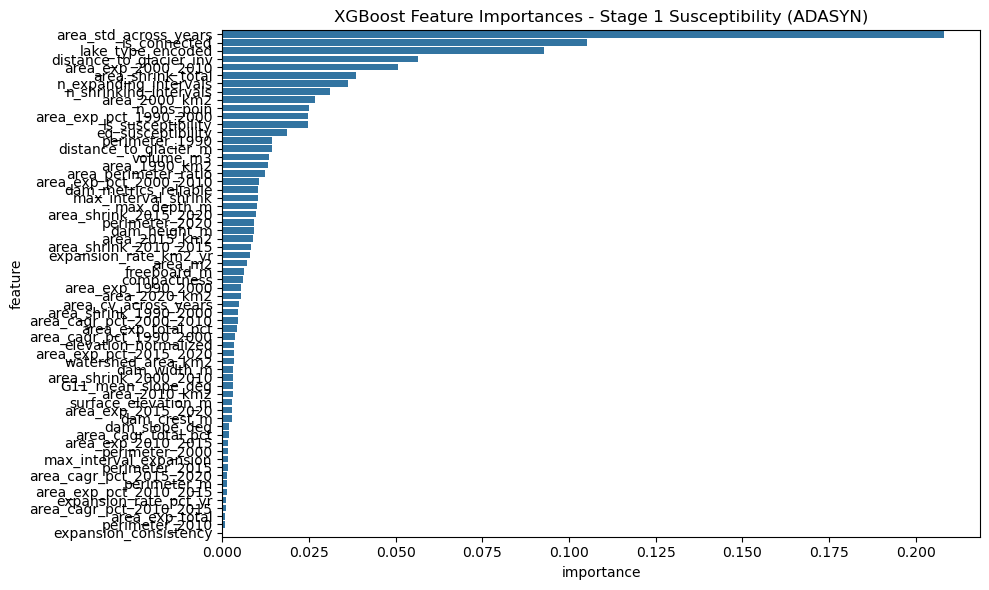


Done. XGBoost + ADASYN outputs saved.


In [104]:
# XGBoost model + ADASYN
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from imblearn.over_sampling import ADASYN
except ImportError as e:
    raise ImportError(
        "ADASYN requires imbalanced-learn. Install with: pip install imbalanced-learn"
    ) from e

# 1) Load
# lakes = gpd.read_file(r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_clean.gpkg")
lakes = lakes_clean.copy()  # Use the cleaned version from previous steps

# 2) Feature prep
le = LabelEncoder()
lakes["lake_type_encoded"] = le.fit_transform(lakes["lake_type"].astype(str))

# Inverse distance feature (higher distance -> lower risk contribution)
lakes["distance_to_glacier_inv"] = 1.0 / (1.0 + lakes["distance_to_glacier_m"].clip(lower=0))

candidate_feature_cols = [
   'perimeter_2020', 'perimeter_1990',
       'perimeter_2000', 'perimeter_2010', 'perimeter_2015', 'area_1990_km2',
       'area_2000_km2', 'area_2010_km2', 'area_2015_km2', 'area_2020_km2',
       'expansion_rate_km2_yr', 'expansion_rate_pct_yr',
     'lake_type', 'distance_to_glacier_m', 'nearest_rgiid',
       'is_connected', 'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility',
       'volume_m3', 'max_depth_m', 'surface_elevation_m', 'area_m2',
       'perimeter_m', 'G11_mean_slope_deg', 'area_exp_1990_2000',
       'area_exp_pct_1990_2000', 'area_cagr_pct_1990_2000',
       'area_exp_2000_2010', 'area_exp_pct_2000_2010',
       'area_cagr_pct_2000_2010', 'area_exp_2010_2015',
       'area_exp_pct_2010_2015', 'area_cagr_pct_2010_2015',
       'area_exp_2015_2020', 'area_exp_pct_2015_2020',
       'area_cagr_pct_2015_2020', 'area_exp_total', 'area_exp_total_pct',
       'area_cagr_total_pct', 'n_expanding_intervals', 'n_shrinking_intervals',
       'area_shrink_1990_2000', 'area_shrink_2000_2010',
       'area_shrink_2010_2015', 'area_shrink_2015_2020', 'area_shrink_total',
       'max_interval_expansion', 'max_interval_shrink', 'watershed_area_km2',
       'compactness', 'area_perimeter_ratio', 'elevation_normalized',
       'expansion_consistency', 'area_std_across_years',
       'area_cv_across_years', 'dam_crest_m', 'dam_height_m',
       'dam_metrics_reliable', 'dam_slope_deg', 'dam_width_m', 'freeboard_m',
       'n_obs_poin', 'geometry','lake_type_encoded','distance_to_glacier_inv'
]

available_feature_cols = [c for c in candidate_feature_cols if c in lakes.columns]
missing_feature_cols = [c for c in candidate_feature_cols if c not in lakes.columns]
if missing_feature_cols:
    print(f"Missing candidate features: {len(missing_feature_cols)}")
    print(missing_feature_cols)

non_numeric_cols = [c for c in available_feature_cols if not pd.api.types.is_numeric_dtype(lakes[c])]
if non_numeric_cols:
    print(f"Dropping non-numeric features: {non_numeric_cols}")

feature_cols = [c for c in available_feature_cols if c not in non_numeric_cols]
if len(feature_cols) == 0:
    raise ValueError("No usable numeric feature columns available for modeling.")

# Ensure model matrix is numeric for ADASYN / XGB
lakes[feature_cols] = lakes[feature_cols].replace([np.inf, -np.inf], np.nan)
if "glof_happened" not in lakes.columns:
    raise KeyError("Target column 'glof_happened' not found.")

model_df = lakes.dropna(subset=feature_cols + ["glof_happened"]).copy()
if len(model_df) == 0:
    raise ValueError("No rows left after filtering for non-missing features and target.")

X = model_df[feature_cols].values
y = model_df["glof_happened"].astype(int).values

n_pos = int(y.sum())
n_neg = int((y == 0).sum())
print(f"Class distribution -- GLOF: {n_pos}  No GLOF: {n_neg}")
print(f"Imbalance ratio: 1:{max(1, n_neg // max(1, n_pos))}")

if n_pos == 0:
    raise ValueError("No positive class rows found after filtering.")

# 3) Spatial groups
centroids = model_df.geometry.centroid.to_crs("EPSG:4326")
lat_bins = pd.cut(centroids.y, bins=5, labels=False)
lon_bins = pd.cut(centroids.x, bins=5, labels=False)
spatial_blocks = lat_bins * 5 + lon_bins

n_splits = 5 if n_pos >= 50 else 2
cv = StratifiedGroupKFold(n_splits=n_splits)

# 4) XGBoost model
# With ADASYN, keep scale_pos_weight neutral (1.0) to avoid double compensation.
xgb_model = XGBClassifier(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=2,
    subsample=0.7,
    colsample_bytree=1,
    reg_lambda=2.0,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=2.0,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

fold_metrics = []
oof_probs = np.full(len(y), np.nan)

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=spatial_blocks)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Apply ADASYN only to training data (no leakage)
    pos_train = int((y_train == 1).sum())
    if pos_train >= 6:
        n_neighbors = min(5, pos_train - 1)
        adasyn = ADASYN(random_state=42, n_neighbors=n_neighbors)
        X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)
    else:
        X_train_res, y_train_res = X_train, y_train

    xgb_model.fit(X_train_res, y_train_res)

    val_probs = xgb_model.predict_proba(X_val)[:, 1]
    oof_probs[val_idx] = val_probs

    fold_ap = average_precision_score(y_val, val_probs)
    try:
        fold_auc = roc_auc_score(y_val, val_probs)
    except ValueError:
        fold_auc = np.nan

    p, r, t = precision_recall_curve(y_val, val_probs)
    if len(t) > 0:
        f2 = (5 * p[:-1] * r[:-1]) / (4 * p[:-1] + r[:-1] + 1e-12)
        best_t = float(t[np.nanargmax(f2)])
    else:
        best_t = 0.5

    val_preds = (val_probs >= best_t).astype(int)
    report = classification_report(y_val, val_preds, output_dict=True, zero_division=0)

    fold_metrics.append({
        "fold": fold + 1,
        "roc_auc": fold_auc,
        "avg_precision": fold_ap,
        "threshold": best_t,
        "precision_glof": report.get("1", {}).get("precision", np.nan),
        "recall_glof": report.get("1", {}).get("recall", np.nan),
        "f1_glof": report.get("1", {}).get("f1-score", np.nan),
    })

    print(
        f"Fold {fold+1} -- AUC: {fold_auc if not np.isnan(fold_auc) else float('nan'):.3f}  "
        f"AP: {fold_ap:.3f}  Recall(GLOF): {report.get('1', {}).get('recall', 0):.3f}"
    )

metrics_df = pd.DataFrame(fold_metrics)
print("\nXGB CV Summary (ADASYN)")
print(metrics_df.drop("fold", axis=1).agg(["mean", "std"]).round(3))

valid_oof = ~np.isnan(oof_probs)
print(f"\nOverall OOF AP:  {average_precision_score(y[valid_oof], oof_probs[valid_oof]):.3f}")
try:
    print(f"Overall OOF AUC: {roc_auc_score(y[valid_oof], oof_probs[valid_oof]):.3f}")
except ValueError:
    print("Overall OOF AUC: NA")

# Global threshold from OOF by F2
p_all, r_all, t_all = precision_recall_curve(y[valid_oof], oof_probs[valid_oof])
if len(t_all) > 0:
    f2_all = (5 * p_all[:-1] * r_all[:-1]) / (4 * p_all[:-1] + r_all[:-1] + 1e-12)
    best_threshold = float(t_all[np.nanargmax(f2_all)])
else:
    best_threshold = 0.5
print(f"Chosen XGB threshold (F2-optimal): {best_threshold:.3f}")

# 5) Final fit on all data with ADASYN
if n_pos >= 6:
    adasyn_final = ADASYN(random_state=42, n_neighbors=min(5, n_pos - 1))
    X_final, y_final = adasyn_final.fit_resample(X, y)
else:
    X_final, y_final = X, y

xgb_model.fit(X_final, y_final)
model_df["xgb_glof_score"] = xgb_model.predict_proba(X)[:, 1]
model_df["xgb_glof_predicted_class"] = (model_df["xgb_glof_score"] >= best_threshold).astype(int)
model_df["xgb_glof_class"] = pd.cut(
    model_df["xgb_glof_score"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=["Very Low", "Low", "Moderate", "High", "Very High"]
)

# Write back to full lakes
lakes["xgb_glof_score"] = np.nan
lakes["xgb_glof_predicted_class"] = pd.Series([pd.NA] * len(lakes), dtype="Int64")
lakes["xgb_glof_class"] = pd.Series([np.nan] * len(lakes), dtype="object")

lakes.loc[model_df.index, "xgb_glof_score"] = model_df["xgb_glof_score"].values
lakes.loc[model_df.index, "xgb_glof_predicted_class"] = model_df["xgb_glof_predicted_class"].astype("Int64").values
lakes.loc[model_df.index, "xgb_glof_class"] = model_df["xgb_glof_class"].astype(str).values

# 6) Feature importance
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nXGB Feature Importances (ADASYN)")
print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("XGBoost Feature Importances - Stage 1 Susceptibility (ADASYN)")
plt.tight_layout()
plt.savefig(r"D:\Rubel\M.Tech\MTP\Phase 2\xgb_feature_importance_adasyn.png", dpi=150)
plt.show()

# 7) Save
lakes.to_file(r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_susceptibility_xgb_adasyn.gpkg", driver="GPKG")
metrics_df.to_csv(r"D:\Rubel\M.Tech\MTP\Phase 2\xgb_cv_metrics_adasyn.csv", index=False)

print("\nDone. XGBoost + ADASYN outputs saved.")

In [107]:
lakes_clean['dam_slope_deg'].describe()

count    6922.000000
mean        5.986197
std         6.380166
min         0.000000
25%         1.132386
50%         3.777251
75%         8.699836
max        47.460675
Name: dam_slope_deg, dtype: float64

In [ ]:
# XGBoost tuning for high-recall GLOF detection (spatial CV)
import geopandas as gpd
import pandas as pd
import numpy as np
from itertools import product
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Load data
# lakes = gpd.read_file(r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_clean.gpkg")

# Feature prep
le = LabelEncoder()
lakes["lake_type_encoded"] = le.fit_transform(lakes["lake_type"].astype(str))
lakes["distance_to_glacier_inv"] = 1.0 / (1.0 + lakes["distance_to_glacier_m"].clip(lower=0))

candidate_feature_cols = [
    'perimeter_2020', 'perimeter_1990',
       'perimeter_2000', 'perimeter_2010', 'perimeter_2015', 'area_1990_km2',
       'area_2000_km2', 'area_2010_km2', 'area_2015_km2', 'area_2020_km2',
       'expansion_rate_km2_yr', 'expansion_rate_pct_yr',
       'is_connected', 'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility',
       'volume_m3', 'max_depth_m', 'surface_elevation_m', 'area_m2',
       'perimeter_m', 'G11_mean_slope_deg', 'area_exp_1990_2000',
       'area_exp_pct_1990_2000', 'area_cagr_pct_1990_2000',
       'area_exp_2000_2010', 'area_exp_pct_2000_2010',
       'area_cagr_pct_2000_2010', 'area_exp_2010_2015',
       'area_exp_pct_2010_2015', 'area_cagr_pct_2010_2015',
       'area_exp_2015_2020', 'area_exp_pct_2015_2020',
       'area_cagr_pct_2015_2020', 'area_exp_total', 'area_exp_total_pct',
       'area_cagr_total_pct', 'n_expanding_intervals', 'n_shrinking_intervals',
       'area_shrink_1990_2000', 'area_shrink_2000_2010',
       'area_shrink_2010_2015', 'area_shrink_2015_2020', 'area_shrink_total',
       'max_interval_expansion', 'max_interval_shrink', 'watershed_area_km2',
       'compactness', 'area_perimeter_ratio', 'elevation_normalized',
       'expansion_consistency', 'area_std_across_years',
       'area_cv_across_years', 'dam_crest_m', 'dam_height_m',
       'dam_metrics_reliable', 'dam_slope_deg', 'dam_width_m', 'freeboard_m',
       'n_obs_poin','lake_type_encoded','distance_to_glacier_inv'
]

available_feature_cols = [c for c in candidate_feature_cols if c in lakes.columns]
non_numeric_cols = [c for c in available_feature_cols if not pd.api.types.is_numeric_dtype(lakes[c])]
if non_numeric_cols:
    print(f"Dropping non-numeric features: {non_numeric_cols}")
feature_cols = [c for c in available_feature_cols if c not in non_numeric_cols]

if "glof_happened" not in lakes.columns:
    raise KeyError("Column 'glof_happened' not found in lakes_clean.gpkg")

# Clean invalid values before filtering
lakes[feature_cols] = lakes[feature_cols].replace([np.inf, -np.inf], np.nan)
model_df = lakes.dropna(subset=feature_cols + ["glof_happened"]).copy()
X = model_df[feature_cols].values
y = model_df["glof_happened"].astype(int).values

n_pos = int(y.sum())
n_neg = int((y == 0).sum())
if n_pos == 0:
    raise ValueError("No positive class rows found after filtering.")

# Spatial groups (same logic as current model)
centroids = model_df.geometry.centroid.to_crs("EPSG:4326")
lat_bins = pd.cut(centroids.y, bins=5, labels=False)
lon_bins = pd.cut(centroids.x, bins=5, labels=False)
spatial_blocks = lat_bins * 5 + lon_bins

n_splits = 5 if n_pos >= 50 else 3
cv = StratifiedGroupKFold(n_splits=n_splits)

# Compact grid (recall-oriented, still practical runtime)
param_grid = {
    "n_estimators": [800, 1200, 2000],
    "learning_rate": [0.03, 0.05],
    "max_depth": [3, 4, 5],
    "min_child_weight": [1, 2, 4],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
    "reg_lambda": [1.0, 2.0],
    'scale_pos_weight': [1, 2, 5, 10]  # Include some weight tuning for imbalance,
}

combos = list(product(
    param_grid["n_estimators"],
    param_grid["learning_rate"],
    param_grid["max_depth"],
    param_grid["min_child_weight"],
    param_grid["subsample"],
    param_grid["colsample_bytree"],
    param_grid["reg_lambda"],
    param_grid["scale_pos_weight"],
))

# To limit runtime, evaluate first N combinations
max_trials = 36
combos = combos[:max_trials]

results = []

for trial_id, (n_est, lr, md, mcw, ss, cs, rl, spw) in enumerate(combos, start=1):
    fold_ap = []
    fold_recall = []
    fold_precision = []

    for train_idx, val_idx in cv.split(X, y, groups=spatial_blocks):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = XGBClassifier(
            n_estimators=n_est,
            learning_rate=lr,
            max_depth=md,
            min_child_weight=mcw,
            subsample=ss,
            colsample_bytree=cs,
            reg_lambda=rl,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=spw,
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
        )

        model.fit(X_train, y_train)
        probs = model.predict_proba(X_val)[:, 1]

        # Recall-focused threshold (maximize F2 on this fold)
        p, r, t = precision_recall_curve(y_val, probs)
        if len(t) > 0:
            f2 = (5 * p[:-1] * r[:-1]) / (4 * p[:-1] + r[:-1] + 1e-12)
            best_idx = int(np.nanargmax(f2))
            best_p = float(p[:-1][best_idx])
            best_r = float(r[:-1][best_idx])
        else:
            best_p, best_r = 0.0, 0.0

        fold_ap.append(float(average_precision_score(y_val, probs)))
        fold_precision.append(best_p)
        fold_recall.append(best_r)

    results.append({
        "trial": trial_id,
        "n_estimators": n_est,
        "learning_rate": lr,
        "max_depth": md,
        "min_child_weight": mcw,
        "subsample": ss,
        "colsample_bytree": cs,
        "reg_lambda": rl,
        'scale_pos_weight': spw,
        "mean_ap": float(np.mean(fold_ap)),
        "mean_precision": float(np.mean(fold_precision)),
        "mean_recall": float(np.mean(fold_recall)),
    })

results_df = pd.DataFrame(results)

# Rank by recall first, then AP, then precision
results_df = results_df.sort_values(
    by=["mean_recall", "mean_ap", "mean_precision"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Top 10 tuning results:")
print(results_df.head(10).to_string(index=False))

best_params = results_df.iloc[0]
print("\nBest params (recall-priority):")
print(best_params[[
    "n_estimators", "learning_rate", "max_depth", "min_child_weight",
    "subsample", "colsample_bytree", "reg_lambda", "mean_recall", "mean_ap", "mean_precision"
]])

# Save tuning table
results_df.to_csv(r"D:\Rubel\M.Tech\MTP\Phase 2\xgb_tuning_results.csv", index=False)
print("\nSaved tuning results to xgb_tuning_results.csv")

Dropping non-numeric features: ['wse_m_dam']
Top 10 tuning results:
 trial  n_estimators  learning_rate  max_depth  min_child_weight  subsample  colsample_bytree  reg_lambda  scale_pos_weight  mean_ap  mean_precision  mean_recall
    27           800           0.03          3                 1        0.9               0.9         1.0                 5 0.120858        0.106005     0.336142
    30           800           0.03          3                 1        0.9               0.9         2.0                 2 0.138680        0.131730     0.334554
    10           800           0.03          3                 1        0.8               0.9         1.0                 2 0.150269        0.329167     0.326129
     9           800           0.03          3                 1        0.8               0.9         1.0                 1 0.145781        0.156689     0.314164
    36           800           0.03          3                 2        0.8               0.8         1.0                1

# pytorch

In [302]:
# PyTorch baseline for rare-event learning: Class-Weighted BCE vs Focal Loss
import os
import copy
import numpy as np
import pandas as pd
import geopandas as gpd
import torch
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import QuantileTransformer, LabelEncoder
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ------------------------- 0) Reproducibility -------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------- 1) Data prep -------------------------
# lakes = gpd.read_file(r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_clean.gpkg")
lakes = lakes_clean.copy()

le = LabelEncoder()
lakes["lake_type_encoded"] = le.fit_transform(lakes["lake_type"].astype(str))
lakes["distance_to_glacier_inv"] = 1.0 / (1.0 + lakes["distance_to_glacier_m"].clip(lower=0))

feature_cols = [
   'perimeter_2020', 'perimeter_1990',
       'perimeter_2000', 'perimeter_2010', 'perimeter_2015', 'area_1990_km2',
       'area_2000_km2', 'area_2010_km2', 'area_2015_km2', 'area_2020_km2',
       'is_connected', 'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility',
       'volume_m3', 'max_depth_m', 'surface_elevation_m', 'area_m2',
       'perimeter_m', 'G11_mean_slope_deg', 'area_exp_1990_2000',
       'area_exp_pct_1990_2000', 'area_cagr_pct_1990_2000',
       'area_exp_2000_2010', 'area_exp_pct_2000_2010',
       'area_cagr_pct_2000_2010', 'area_exp_2010_2015',
       'area_exp_pct_2010_2015', 'area_cagr_pct_2010_2015',
       'area_exp_2015_2020', 'area_exp_pct_2015_2020',
       'area_cagr_pct_2015_2020', 'area_exp_total', 'area_exp_total_pct',
       'area_cagr_total_pct', 'n_expanding_intervals', 'n_shrinking_intervals',
       'area_shrink_1990_2000', 'area_shrink_2000_2010',
       'area_shrink_2010_2015', 'area_shrink_2015_2020', 'area_shrink_total',
       'max_interval_expansion', 'max_interval_shrink', 'watershed_area_km2',
       'compactness', 'area_perimeter_ratio', 'elevation_normalized',
       'expansion_consistency', 'area_std_across_years',
       'area_cv_across_years', 'dam_crest_m', 'dam_height_m',
       'dam_metrics_reliable', 'dam_slope_deg', 'dam_width_m', 'freeboard_m',
       'n_obs_poin','lake_type_encoded','distance_to_glacier_inv']

feature_cols = [c for c in feature_cols if c in lakes.columns]
non_numeric_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(lakes[c])]
if non_numeric_cols:
    print(f"Dropping non-numeric features: {non_numeric_cols}")
feature_cols = [c for c in feature_cols if c not in non_numeric_cols]

model_df = lakes.dropna(subset=feature_cols + ["glof_happened"]).copy()
X = model_df[feature_cols].to_numpy(dtype=np.float32)
y = model_df["glof_happened"].astype(int).to_numpy(dtype=np.int64)

n_pos = int(y.sum())
n_neg = int((y == 0).sum())
if n_pos == 0:
    raise ValueError("No positive class rows found after filtering.")

centroids = model_df.geometry.centroid.to_crs("EPSG:4326")
lat_bins = pd.cut(centroids.y, bins=5, labels=False)
lon_bins = pd.cut(centroids.x, bins=5, labels=False)
spatial_blocks = (lat_bins * 5 + lon_bins).to_numpy()

print(f"Class distribution -- GLOF: {n_pos}  No GLOF: {n_neg}")
print(f"Imbalance ratio (neg:pos): {n_neg}:{n_pos} = {n_neg / max(1, n_pos):.2f}")

# ------------------------- 2) Model + losses -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class MLP(nn.Module):
    def __init__(self, in_features: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.25),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.20),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.20),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.10),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.10),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

class FocalLossWithLogits(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="sum"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * ((1 - p_t) ** self.gamma) * bce
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

# Choose one: "weighted_bce" or "focal"
LOSS_MODE = "weighted_bce"

# For weighted BCE: set positive-class penalty based on imbalance
pos_weight_value = float(n_neg / max(1, n_pos)) * 20

# Focal parameters: alpha should be higher when positives are rare
focal_alpha = min(0.95, max(0.25, pos_weight_value / (1.0 + pos_weight_value)))
focal_gamma = 1.0

# ------------------------- 3) Training settings -------------------------
n_splits = 5 if n_pos >= 50 else 3
cv = StratifiedGroupKFold(n_splits=n_splits)

epochs = 500
batch_size = 128
lr = 1e-4
weight_decay = 1e-4
patience = 30
min_delta = 1e-4

fold_rows = []
oof_probs = np.full(len(y), np.nan, dtype=float)

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=spatial_blocks), start=1):
    X_train_raw, X_val_raw = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    scaler = QuantileTransformer(
        n_quantiles=min(1000, max(20, len(train_idx))),
        output_distribution="uniform",
        random_state=SEED,
    )
    X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
    X_val = scaler.transform(X_val_raw).astype(np.float32)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    model = MLP(in_features=X.shape[1]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-6
    )

    if LOSS_MODE == "weighted_bce":
        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
        )
    else:
        criterion = FocalLossWithLogits(alpha=focal_alpha, gamma=focal_gamma)

    best_fold_ap = -1.0
    best_state = None
    bad_epochs = 0
    early_stopped = False

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_probs_epoch = torch.sigmoid(val_logits).cpu().numpy()

        val_ap = average_precision_score(y_val, val_probs_epoch)
        scheduler.step(val_ap)

        if val_ap > best_fold_ap + min_delta:
            best_fold_ap = val_ap
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                early_stopped = True
                print(f"Fold {fold}: early stopping at epoch {epoch + 1} | best_val_ap={best_fold_ap:.4f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_probs = torch.sigmoid(val_logits).cpu().numpy()

    oof_probs[val_idx] = val_probs

    fold_ap = average_precision_score(y_val, val_probs)
    try:
        fold_auc = roc_auc_score(y_val, val_probs)
    except ValueError:
        fold_auc = np.nan

    p, r, t = precision_recall_curve(y_val, val_probs)
    if len(t) > 0:
        f2 = (5 * p[:-1] * r[:-1]) / (4 * p[:-1] + r[:-1] + 1e-12)
        best_t = float(t[np.nanargmax(f2)])
    else:
        best_t = 0.5

    fold_rows.append({
        "fold": fold,
        "auc": fold_auc,
        "ap": float(fold_ap),
        "best_t_f2": best_t,
        "best_val_ap_earlystop": float(best_fold_ap),
        "early_stopped": early_stopped,
    })

    print(f"Fold {fold} | AUC: {fold_auc if not np.isnan(fold_auc) else float('nan'):.3f} | AP: {fold_ap:.3f}")

# ------------------------- 4) OOF summary -------------------------
cv_df = pd.DataFrame(fold_rows)
print("\nCV summary:")
print(cv_df.drop(columns=["fold"]).agg(["mean", "std"]).round(4))

valid = ~np.isnan(oof_probs)
oof_ap = average_precision_score(y[valid], oof_probs[valid])
try:
    oof_auc = roc_auc_score(y[valid], oof_probs[valid])
except ValueError:
    oof_auc = np.nan

p_all, r_all, t_all = precision_recall_curve(y[valid], oof_probs[valid])
if len(t_all) > 0:
    f2_all = (5 * p_all[:-1] * r_all[:-1]) / (4 * p_all[:-1] + r_all[:-1] + 1e-12)
    best_threshold = float(t_all[np.nanargmax(f2_all)])
else:
    best_threshold = 0.5

print(f"\nLOSS_MODE: {LOSS_MODE}")
print(f"OOF AP: {oof_ap:.4f}")
print(f"OOF AUC: {oof_auc if not np.isnan(oof_auc) else float('nan'):.4f}")
print(f"F2-optimal threshold: {best_threshold:.4f}")
print(f"Early-stopped folds: {int(cv_df['early_stopped'].sum())}/{len(cv_df)}")

# Save metrics and OOF probabilities
out_dir = r"D:\Rubel\M.Tech\MTP\Phase 2"
metrics_name = f"torch_{LOSS_MODE}_cv_metrics.csv"
oof_name = f"torch_{LOSS_MODE}_oof_probs.csv"
metrics_path = os.path.join(out_dir, metrics_name)
oof_path = os.path.join(out_dir, oof_name)

cv_df.to_csv(metrics_path, index=False)
pd.DataFrame({"y_true": y, "oof_prob": oof_probs}).to_csv(oof_path, index=False)

print(f"Saved metrics: {metrics_path}")
print(f"Saved OOF probs: {oof_path}")

Dropping non-numeric features: ['wse_m_dam']
Class distribution -- GLOF: 42  No GLOF: 6880
Imbalance ratio (neg:pos): 6880:42 = 163.81
Using device: cuda
Fold 1: early stopping at epoch 57 | best_val_ap=0.0476
Fold 1 | AUC: 0.756 | AP: 0.048
Fold 2: early stopping at epoch 36 | best_val_ap=0.0834
Fold 2 | AUC: 0.840 | AP: 0.083
Fold 3: early stopping at epoch 37 | best_val_ap=0.0864
Fold 3 | AUC: 0.716 | AP: 0.086

CV summary:
         auc      ap  best_t_f2  best_val_ap_earlystop  early_stopped
mean  0.7704  0.0725     0.9185                 0.0725            1.0
std   0.0634  0.0216     0.0643                 0.0216            0.0

LOSS_MODE: weighted_bce
OOF AP: 0.0297
OOF AUC: 0.7594
F2-optimal threshold: 0.8486
Early-stopped folds: 3/3
Saved metrics: D:\Rubel\M.Tech\MTP\Phase 2\torch_weighted_bce_cv_metrics.csv
Saved OOF probs: D:\Rubel\M.Tech\MTP\Phase 2\torch_weighted_bce_oof_probs.csv


In [303]:
import numpy as np
import pandas as pd
oof_probs = pd.read_csv(r'torch_weighted_bce_oof_probs.csv')
probs = oof_probs["oof_prob"]

print("Probability distribution:")
print(f"  > 0.99  : {(probs > 0.99).sum()} lakes")
print(f"  0.5ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“0.99: {((probs > 0.5) & (probs <= 0.99)).sum()} lakes")
print(f"  0.1ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“0.5 : {((probs > 0.1) & (probs <= 0.5)).sum()} lakes")
print(f"  < 0.1   : {(probs < 0.1).sum()} lakes")

Probability distribution:
  > 0.99  : 33 lakes
  0.5ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“0.99: 3656 lakes
  0.1ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“0.5 : 3051 lakes
  < 0.1   : 182 lakes


In [304]:
y_true = oof_probs["y_true"].values
probs  = oof_probs["oof_prob"].values

# Where are the actual GLOF lakes in the distribution?
glof_probs     = probs[y_true == 1]
non_glof_probs = probs[y_true == 0]

print(f"ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ Actual GLOF lakes (n=42) probability distribution ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬")
print(f"  > 0.99  : {(glof_probs > 0.99).sum()}")
print(f"  0.5ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“0.99: {((glof_probs > 0.5) & (glof_probs <= 0.99)).sum()}")
print(f"  0.1ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“0.5 : {((glof_probs > 0.1) & (glof_probs <= 0.5)).sum()}")
print(f"  < 0.1   : {(glof_probs < 0.1).sum()}")
print(f"\nMedian prob for GLOF lakes:     {np.median(glof_probs):.4f}")
print(f"Median prob for non-GLOF lakes: {np.median(non_glof_probs):.4f}")

# Recall at different operating thresholds
print(f"\nÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ Recall at different thresholds ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬")
for thresh in [0.9, 0.7, 0.5, 0.3, 0.1]:
    preds    = (probs >= thresh).astype(int)
    tp       = ((preds == 1) & (y_true == 1)).sum()
    fp       = ((preds == 1) & (y_true == 0)).sum()
    recall   = tp / 42
    flagged  = tp + fp
    print(f"  Threshold {thresh:.1f} ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ "
          f"Recall: {recall:.2f} ({tp}/42 GLOF caught)  "
          f"Flagged: {flagged} lakes  "
          f"Precision: {tp/flagged:.3f}" if flagged > 0 else "  No lakes flagged")

# Top-N analysis ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â operationally most meaningful
print(f"\nÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ GLOF lakes captured in top-N ranked ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬")
ranked_idx = np.argsort(probs)[::-1]
for n in [50, 100, 200, 350, 500,1000,2000,5000]:
    hits = y_true[ranked_idx[:n]].sum()
    print(f"  Top {n:4d} lakes ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ {hits}/42 GLOF captured "
          f"({hits/42*100:.0f}% recall)")

ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ Actual GLOF lakes (n=42) probability distribution ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬
  > 0.99  : 3
  0.5ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“0.99: 33
  0.1ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“0.5 : 6
  < 0.1   : 0

Median prob for GLOF lakes:     0.8182
Median prob for non-GLOF lakes: 0.5221

ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ Recall at different thresholds ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬
  Threshold 0.9 ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Recall: 0.24 (10/42 GLOF caught)  Flagged: 426 lakes  Precision: 0.023
  Threshold 0.7 ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Recall: 0.62 (26/42 GLOF caught)  Flagged: 1819 lakes  Precision: 0.014
  Threshold 0.5 ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Recall: 0.86 (36/42 GLOF caught)  Flagged: 3689 lakes  Precision: 0.010
  Threshold 0.3 ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Recall: 0.95 (40/42 GLOF caught)  Flagged: 5518 lakes  Precision: 0.007
  Threshold 0.1 ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Recall: 1.00 (42/42 GLOF caught)  Flagged: 6740 lakes  Precision: 0.006

ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ GLOF lakes captured in 

In [325]:
# Improved PyTorch rare-event model (new cell): balanced sampler + hybrid loss + early stopping
import os
import copy
import random
import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, QuantileTransformer
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# ------------------------- 0) Reproducibility -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------- 1) Data prep -------------------------
# lakes = gpd.read_file(r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_clean.gpkg")
lakes = lakes_clean.copy()
le = LabelEncoder()
lakes["lake_type_encoded"] = le.fit_transform(lakes["lake_type"].astype(str))
lakes["distance_to_glacier_inv"] = 1.0 / (1.0 + lakes["distance_to_glacier_m"].clip(lower=0))

candidate_feature_cols = [
  'perimeter_2020', 'perimeter_1990',
       'perimeter_2000', 'perimeter_2010', 'perimeter_2015', 'area_1990_km2',
       'area_2000_km2', 'area_2010_km2', 'area_2015_km2', 'area_2020_km2',
       'is_connected', 'eq_susceptibility', 'ls_susceptibility',
       'volume_m3', 'max_depth_m', 'surface_elevation_m', 'area_m2',
       'perimeter_m', 'G11_mean_slope_deg', 'area_exp_1990_2000',
       'area_exp_pct_1990_2000', 'area_cagr_pct_1990_2000',
       'area_exp_2000_2010', 'area_exp_pct_2000_2010',
       'area_cagr_pct_2000_2010', 'area_exp_2010_2015',
       'area_exp_pct_2010_2015', 'area_cagr_pct_2010_2015',
       'area_exp_2015_2020', 'area_exp_pct_2015_2020',
       'area_cagr_pct_2015_2020', 'area_exp_total', 'area_exp_total_pct',
       'area_cagr_total_pct', 'n_expanding_intervals', 'n_shrinking_intervals',
       'area_shrink_1990_2000', 'area_shrink_2000_2010',
       'area_shrink_2010_2015', 'area_shrink_2015_2020', 'area_shrink_total',
       'max_interval_expansion', 'max_interval_shrink', 'watershed_area_km2',
       'compactness', 'area_perimeter_ratio', 'elevation_normalized',
       'expansion_consistency', 'area_std_across_years',
       'area_cv_across_years', 'dam_crest_m', 'dam_height_m',
       'dam_metrics_reliable', 'dam_slope_deg', 'dam_width_m', 'freeboard_m',
       'n_obs_poin','lake_type_encoded','distance_to_glacier_inv'
]

available_feature_cols = [c for c in candidate_feature_cols if c in lakes.columns]
missing_feature_cols = [c for c in candidate_feature_cols if c not in lakes.columns]
if missing_feature_cols:
    print(f"Missing candidate features: {len(missing_feature_cols)}")
    print(missing_feature_cols)

non_numeric_cols = [
    c for c in available_feature_cols
    if not pd.api.types.is_numeric_dtype(lakes[c])
]
if non_numeric_cols:
    print(f"Dropping non-numeric features: {non_numeric_cols}")

feature_cols = [c for c in available_feature_cols if c not in non_numeric_cols]
if len(feature_cols) == 0:
    raise ValueError("No usable numeric feature columns available for modeling.")

if "glof_happened" not in lakes.columns:
    raise KeyError("Column 'glof_happened' not found in data.")

# Remove inf artifacts from ratio/cagr features before filtering rows
lakes[feature_cols] = lakes[feature_cols].replace([np.inf, -np.inf], np.nan)
model_df = lakes.dropna(subset=feature_cols + ["glof_happened"]).copy()
if len(model_df) == 0:
    raise ValueError("No rows left after filtering for non-missing features and target.")

X_df = model_df[feature_cols].copy()
y = model_df["glof_happened"].astype(int).to_numpy(dtype=np.int64)

# Light log transforms for heavy-tailed variables
for c in [
    "perimeter_m", "area_m2", "volume_m3",'perimeter_2020', 'perimeter_1990', 'perimeter_2000', 'perimeter_2010', 'perimeter_2015',
    'area_1990_km2', 'area_2000_km2', 'area_2010_km2', 'area_2015_km2', 'area_2020_km2'
]:
    if c in X_df.columns:
        X_df[c] = np.log1p(np.clip(X_df[c].to_numpy(dtype=np.float64), a_min=0, a_max=None))

X = X_df.to_numpy(dtype=np.float32)
n_pos = int(y.sum())
n_neg = int((y == 0).sum())
if n_pos == 0:
    raise ValueError("No positive class rows found after filtering.")

centroids = model_df.geometry.centroid.to_crs("EPSG:4326")
lat_bins = pd.cut(centroids.y, bins=5, labels=False)
lon_bins = pd.cut(centroids.x, bins=5, labels=False)
spatial_blocks = (lat_bins * 5 + lon_bins).to_numpy()

print(f"Using {len(feature_cols)} features")
print(f"Class distribution -- GLOF: {n_pos} | No GLOF: {n_neg}")
print(f"Imbalance ratio (neg:pos): {n_neg}:{n_pos} = {n_neg / max(1, n_pos):.2f}")

# ------------------------- 2) Model and losses -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class ResidualMLP(nn.Module):
    def __init__(self, in_features: int, hidden: int = 256, dropout: float = 0.20):
        super().__init__()
        self.inp = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
        )
        self.block1 = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
        )
        self.block3 = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
        )
        self.block4 = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
        )
        self.block5 = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
        )

        self.out = nn.Linear(hidden, 1)

    def forward(self, x):
        h =  self.inp(x)
        h =  h + self.block1(h)
        h =  h + self.block2(h)
        h =  h + self.block3(h)
        h =  h + self.block4(h)
        h =  h + self.block5(h)
        return self.out(h).squeeze(1)

class FocalLossWithLogits(nn.Module):
    def __init__(self, alpha=0.25, gamma=1.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="sum")
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * ((1 - p_t) ** self.gamma) * bce
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

# Hybrid objective: weighted BCE + focal
pos_weight_value = float(n_neg / max(1, n_pos)) * 10 # amplify imbalance penalty for BCE
focal_alpha = 0.8 # moderate alpha for focal to focus on positives without ignoring negatives
bce_weight = 0.2
focal_weight = 0.8

# ------------------------- 3) CV + training -------------------------
n_splits = 5 if n_pos >= 50 else 2
cv = StratifiedGroupKFold(n_splits=n_splits)

max_epochs = 300
batch_size = 128
lr = 1e-4
weight_decay = 5e-4
patience = 35

fold_rows = []
oof_probs = np.full(len(y), np.nan, dtype=float)

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=spatial_blocks), start=1):
    X_train_raw, X_val_raw = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    scaler = QuantileTransformer(
        n_quantiles=min(1000, max(20, len(train_idx))),
        output_distribution="uniform",
        random_state=SEED,
    )
    X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
    X_val = scaler.transform(X_val_raw).astype(np.float32)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)

    # Balanced mini-batches via weighted sampling
    class_counts = np.bincount(y_train)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[y_train]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size,
        sampler=sampler,
        drop_last=False,
    )

    model = ResidualMLP(in_features=X.shape[1], hidden=256, dropout=0.20).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=10, min_lr=1e-5
    )

    bce_criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
    )
    focal_criterion = FocalLossWithLogits(alpha=focal_alpha, gamma=2.0)

    best_ap = -1.0
    best_state = None
    bad_epochs = 0

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss_bce = bce_criterion(logits, yb)
            loss_focal = focal_criterion(logits, yb)
            loss = bce_weight * loss_bce + focal_weight * loss_focal
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_probs = torch.sigmoid(val_logits).cpu().numpy()

        val_ap = average_precision_score(y_val, val_probs)
        scheduler.step(val_ap)

        if val_ap > best_ap + 1e-5:
            best_ap = val_ap
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Fold {fold}: early stopping at epoch {epoch + 1} | best_val_ap={best_ap:.4f}")
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_probs = torch.sigmoid(val_logits).cpu().numpy()

    oof_probs[val_idx] = val_probs

    fold_ap = average_precision_score(y_val, val_probs)
    try:
        fold_auc = roc_auc_score(y_val, val_probs)
    except ValueError:
        fold_auc = np.nan

    p, r, t = precision_recall_curve(y_val, val_probs)
    if len(t) > 0:
        f2 = (5 * p[:-1] * r[:-1]) / (4 * p[:-1] + r[:-1] + 1e-12)
        best_t = float(t[np.nanargmax(f2)])
    else:
        best_t = 0.5

    fold_rows.append({
        "fold": fold,
        "auc": fold_auc,
        "ap": float(fold_ap),
        "best_t_f2": best_t,
        "best_val_ap_earlystop": float(best_ap),
    })

    print(f"Fold {fold} | AP: {fold_ap:.4f} | AUC: {fold_auc if not np.isnan(fold_auc) else float('nan'):.4f} | BestValAP: {best_ap:.4f}")

# ------------------------- 4) OOF summary and save -------------------------
cv_df = pd.DataFrame(fold_rows)
print("\nImproved CV summary:")
print(cv_df.drop(columns=["fold"]).agg(["mean", "std"]).round(4))

valid = ~np.isnan(oof_probs)
oof_ap = average_precision_score(y[valid], oof_probs[valid])
try:
    oof_auc = roc_auc_score(y[valid], oof_probs[valid])
except ValueError:
    oof_auc = np.nan

p_all, r_all, t_all = precision_recall_curve(y[valid], oof_probs[valid])
if len(t_all) > 0:
    f2_all = (5 * p_all[:-1] * r_all[:-1]) / (4 * p_all[:-1] + r_all[:-1] + 1e-12)
    best_threshold = float(t_all[np.nanargmax(f2_all)])
else:
    best_threshold = 0.5

print(f"\nImproved OOF AP: {oof_ap:.4f}")
print(f"Improved OOF AUC: {oof_auc if not np.isnan(oof_auc) else float('nan'):.4f}")
print(f"Improved F2-optimal threshold: {best_threshold:.4f}")

out_dir = r"D:\Rubel\M.Tech\MTP\Phase 2"
cv_out = os.path.join(out_dir, "torch_improved_cv_metrics.csv")
oof_out = os.path.join(out_dir, "torch_improved_oof_probs.csv")
cv_df.to_csv(cv_out, index=False)
pd.DataFrame({"y_true": y, "oof_prob": oof_probs}).to_csv(oof_out, index=False)
print(f"Saved: {cv_out}")
print(f"Saved: {oof_out}")

Using 59 features
Class distribution -- GLOF: 42 | No GLOF: 6880
Imbalance ratio (neg:pos): 6880:42 = 163.81
Using device: cuda
Fold 1: early stopping at epoch 36 | best_val_ap=0.0436
Fold 1 | AP: 0.0436 | AUC: 0.7686 | BestValAP: 0.0436
Fold 2: early stopping at epoch 80 | best_val_ap=0.0781
Fold 2 | AP: 0.0781 | AUC: 0.8162 | BestValAP: 0.0781

Improved CV summary:
         auc      ap  best_t_f2  best_val_ap_earlystop
mean  0.7924  0.0608     0.4993                 0.0608
std   0.0337  0.0244     0.7024                 0.0244

Improved OOF AP: 0.0374
Improved OOF AUC: 0.7399
Improved F2-optimal threshold: 0.9960
Saved: D:\Rubel\M.Tech\MTP\Phase 2\torch_improved_cv_metrics.csv
Saved: D:\Rubel\M.Tech\MTP\Phase 2\torch_improved_oof_probs.csv


In [327]:
import numpy as np
import pandas as pd
oof_probs = pd.read_csv(r'torch_improved_oof_probs.csv')
probs = oof_probs["oof_prob"]

print("Probability distribution:")
print(f"  > 0.99  : {(probs > 0.99).sum()} lakes")
print(f"  0.5ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“0.99: {((probs > 0.5) & (probs <= 0.99)).sum()} lakes")
print(f"  0.1ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“0.5 : {((probs > 0.1) & (probs <= 0.5)).sum()} lakes")
print(f"  < 0.1   : {(probs < 0.1).sum()} lakes")

Probability distribution:
  > 0.99  : 408 lakes
  0.5ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“0.99: 2574 lakes
  0.1ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“0.5 : 483 lakes
  < 0.1   : 3457 lakes


In [328]:
y_true = oof_probs["y_true"].values
probs  = oof_probs["oof_prob"].values

# Where are the actual GLOF lakes in the distribution?
glof_probs     = probs[y_true == 1]
non_glof_probs = probs[y_true == 0]

print(f"ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ Actual GLOF lakes (n=42) probability distribution ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬")
print(f"  > 0.99  : {(glof_probs > 0.99).sum()}")
print(f"  0.5ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“0.99: {((glof_probs > 0.5) & (glof_probs <= 0.99)).sum()}")
print(f"  0.1ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“0.5 : {((glof_probs > 0.1) & (glof_probs <= 0.5)).sum()}")
print(f"  < 0.1   : {(glof_probs < 0.1).sum()}")
print(f"\nMedian prob for GLOF lakes:     {np.median(glof_probs):.4f}")
print(f"Median prob for non-GLOF lakes: {np.median(non_glof_probs):.4f}")

# Recall at different operating thresholds
print(f"\nÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ Recall at different thresholds ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬")
for thresh in [0.9, 0.7, 0.5, 0.3, 0.1]:
    preds    = (probs >= thresh).astype(int)
    tp       = ((preds == 1) & (y_true == 1)).sum()
    fp       = ((preds == 1) & (y_true == 0)).sum()
    recall   = tp / 42
    flagged  = tp + fp
    print(f"  Threshold {thresh:.1f} ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ "
          f"Recall: {recall:.2f} ({tp}/42 GLOF caught)  "
          f"Flagged: {flagged} lakes  "
          f"Precision: {tp/flagged:.3f}" if flagged > 0 else "  No lakes flagged")

# Top-N analysis ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â operationally most meaningful
print(f"\nÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ GLOF lakes captured in top-N ranked ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬")
ranked_idx = np.argsort(probs)[::-1]
for n in [50, 100, 200, 350, 500,1000,2000,5000]:
    hits = y_true[ranked_idx[:n]].sum()
    print(f"  Top {n:4d} lakes ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ {hits}/42 GLOF captured "
          f"({hits/42*100:.0f}% recall)")

ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ Actual GLOF lakes (n=42) probability distribution ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬
  > 0.99  : 14
  0.5ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“0.99: 15
  0.1ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“0.5 : 2
  < 0.1   : 11

Median prob for GLOF lakes:     0.9691
Median prob for non-GLOF lakes: 0.0926

ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ Recall at different thresholds ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬
  Threshold 0.9 ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Recall: 0.60 (25/42 GLOF caught)  Flagged: 1790 lakes  Precision: 0.014
  Threshold 0.7 ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Recall: 0.67 (28/42 GLOF caught)  Flagged: 2642 lakes  Precision: 0.011
  Threshold 0.5 ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Recall: 0.69 (29/42 GLOF caught)  Flagged: 2982 lakes  Precision: 0.010
  Threshold 0.3 ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Recall: 0.74 (31/42 GLOF caught)  Flagged: 3263 lakes  Precision: 0.010
  Threshold 0.1 ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Recall: 0.74 (31/42 GLOF caught)  Flagged: 3465 lakes  Precision: 0.009

ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ÃƒÂ¢Ã¢â‚¬ÂÃ¢â€šÂ¬ GLOF lakes captured 

# Hyperparameter search


#

In [123]:
# Hyperparameter search cell for PyTorch rare-event model
# Tries architecture/loss/preprocessing combinations and saves trial results + best OOF

import os
import copy
import random
import numpy as np
import pandas as pd
import geopandas as gpd
import torch
import torch.nn as nn
from tqdm.auto import tqdm
from itertools import product
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    QuantileTransformer,
    PowerTransformer,
    LabelEncoder,
)
from sklearn.metrics import average_precision_score, roc_auc_score
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# ------------------------- 0) Reproducibility -------------------------
SEED = 14
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------- 1) Data prep -------------------------
# lakes = gpd.read_file(r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_clean.gpkg")
lakes = lakes_clean.copy()

le = LabelEncoder()
lakes["lake_type_encoded"] = le.fit_transform(lakes["lake_type"].astype(str))
lakes["distance_to_glacier_inv"] = 1.0 / (1.0 + lakes["distance_to_glacier_m"].clip(lower=0))

candidate_feature_cols = ['perimeter_2020', 'perimeter_1990',
       'perimeter_2000', 'perimeter_2010', 'perimeter_2015', 'area_1990_km2',
       'area_2000_km2', 'area_2010_km2', 'area_2015_km2', 'area_2020_km2',
       'is_connected', 'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility',
       'volume_m3', 'max_depth_m', 'surface_elevation_m', 'area_m2',
       'perimeter_m', 'G11_mean_slope_deg', 'area_exp_1990_2000',
       'area_exp_pct_1990_2000', 'area_cagr_pct_1990_2000',
       'area_exp_2000_2010', 'area_exp_pct_2000_2010',
       'area_cagr_pct_2000_2010', 'area_exp_2010_2015',
       'area_exp_pct_2010_2015', 'area_cagr_pct_2010_2015',
       'area_exp_2015_2020', 'area_exp_pct_2015_2020',
       'area_cagr_pct_2015_2020', 'area_exp_total', 'area_exp_total_pct',
       'area_cagr_total_pct', 'n_expanding_intervals', 'n_shrinking_intervals',
       'area_shrink_1990_2000', 'area_shrink_2000_2010',
       'area_shrink_2010_2015', 'area_shrink_2015_2020', 'area_shrink_total',
       'max_interval_expansion', 'max_interval_shrink', 'watershed_area_km2',
       'compactness', 'area_perimeter_ratio', 'elevation_normalized',
       'expansion_consistency', 'area_std_across_years',
       'area_cv_across_years', 'dam_crest_m', 'dam_height_m',
       'dam_metrics_reliable', 'dam_slope_deg', 'dam_width_m', 'freeboard_m',
       'n_obs_poin','lake_type_encoded','distance_to_glacier_inv'
]

feature_cols = [c for c in candidate_feature_cols if c in lakes.columns]
if "glof_happened" not in lakes.columns:
    raise KeyError("Column 'glof_happened' not found in lakes_clean.gpkg")

model_df = lakes.dropna(subset=feature_cols + ["glof_happened"]).copy()
X_df_full = model_df[feature_cols].copy()
y = model_df["glof_happened"].astype(int).to_numpy(dtype=np.int64)

n_pos = int(y.sum())
n_neg = int((y == 0).sum())
if n_pos == 0:
    raise ValueError("No positive class rows found after filtering.")

centroids = model_df.geometry.centroid.to_crs("EPSG:4326")
lat_bins = pd.cut(centroids.y, bins=5, labels=False)
lon_bins = pd.cut(centroids.x, bins=5, labels=False)
spatial_blocks = (lat_bins * 5 + lon_bins).to_numpy()

print(f"Using {len(feature_cols)} features")
print(f"Class distribution -- GLOF: {n_pos} | No GLOF: {n_neg}")
print(f"Imbalance ratio (neg:pos): {n_neg}:{n_pos} = {n_neg / max(1, n_pos):.2f}")

# ------------------------- 2) Config space -------------------------
# Requested tuning knobs
hidden_sizes = [256, 384, 512,128]
dropouts = [0.4, 0.2, 0.3]
activations = ["relu", "leakyrelu"]
focal_alphas = [0.25, 0.5, 0.75]
focal_gammas = [1.0, 2.0, 3.0]
pos_weight_amplifiers = [2, 5, 10, 20]
loss_weight_pairs = [
    (0.8, 0.2),
    (0.5, 0.5),
    (0.2, 0.8),
]
preprocess_methods = [

    "quantile_uniform",
]

all_combos = list(product(
    hidden_sizes,
    dropouts,
    activations,
    focal_alphas,
    focal_gammas,
    pos_weight_amplifiers,
    loss_weight_pairs,
    preprocess_methods,
))

# Keep runtime practical by sampling a subset of full grid
MAX_TRIALS = 200
if len(all_combos) > MAX_TRIALS:
    sampled_combos = random.sample(all_combos, MAX_TRIALS)
else:
    sampled_combos = all_combos

print(f"Total possible combos: {len(all_combos)}")
print(f"Running sampled trials: {len(sampled_combos)}")

# ------------------------- 3) Model/loss helpers -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def get_activation(name: str):
    if name == "relu":
        return nn.ReLU()
    if name == "gelu":
        return nn.GELU()
    if name == "leakyrelu":
        return nn.LeakyReLU(negative_slope=0.1)
    raise ValueError(f"Unknown activation: {name}")


class ConfigMLP(nn.Module):
    def __init__(self, in_features: int, hidden: int, dropout: float, activation: str):
        super().__init__()
        h2 = max(16, hidden // 2)
        h3 = max(8, hidden // 4)
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            get_activation(activation),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.Linear(hidden, h2),
            get_activation(activation),
            nn.LayerNorm(h2),
            nn.Dropout(dropout),
            nn.Linear(h2, h3),
            get_activation(activation),
            nn.LayerNorm(h3),
            nn.Dropout(dropout),
            nn.Linear(h3, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


class FocalLossWithLogits(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * ((1 - p_t) ** self.gamma) * bce
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


def make_preprocessor(name: str, n_train: int):
    if name == "standard" or name == "standard_log1p":
        return StandardScaler()
    if name == "robust":
        return RobustScaler()
    if name == "quantile_normal":
        return QuantileTransformer(
            n_quantiles=min(1000, max(20, n_train)),
            output_distribution="normal",
            random_state=SEED,
        )
    if name == "quantile_uniform":
        return QuantileTransformer(
            n_quantiles=min(1000, max(20, n_train)),
            output_distribution="uniform",
            random_state=SEED,
        )
    if name == "power_yeo":
        return PowerTransformer(method="yeo-johnson", standardize=True)
    raise ValueError(f"Unknown preprocessing method: {name}")


# ------------------------- 4) Search loop -------------------------
n_splits = 5 if n_pos >= 50 else 2
cv = StratifiedGroupKFold(n_splits=n_splits)

max_epochs = 500
batch_size = 128
lr = 2e-3
weight_decay = 1e-3
l1_lambda = 1e-6
patience = 25
min_delta = 1e-4
min_epochs = 20

log1p_candidates = [
    c for c in [
        "perimeter_m",
        "area_m2",
        "volume_m3",
        "max_depth_m",
        "Elevation",
        "surface_elevation_m",
        
    ] if c in feature_cols
]

trial_rows = []
best = {
    "ap": -1.0,
    "oof": None,
    "cfg": None,
}

for trial_i, combo in enumerate(tqdm(sampled_combos, desc="Hyperparameter trials", unit="trial"), start=1):
    (
        hidden,
        dropout,
        activation,
        alpha,
        gamma,
        pos_amp,
        loss_pair,
        preprocess_name,
    ) = combo
    bce_weight, focal_weight = loss_pair

    oof_probs = np.full(len(y), np.nan, dtype=float)
    fold_aps = []
    fold_aucs = []

    try:
        for fold, (train_idx, val_idx) in enumerate(cv.split(X_df_full.values, y, groups=spatial_blocks), start=1):
            X_train_df = X_df_full.iloc[train_idx].copy()
            X_val_df = X_df_full.iloc[val_idx].copy()
            y_train, y_val = y[train_idx], y[val_idx]

            # Optional log1p before scaling for heavy-tailed vars
            if preprocess_name == "standard_log1p":
                for c in log1p_candidates:
                    X_train_df[c] = np.log1p(np.clip(X_train_df[c].to_numpy(dtype=np.float64), a_min=0, a_max=None))
                    X_val_df[c] = np.log1p(np.clip(X_val_df[c].to_numpy(dtype=np.float64), a_min=0, a_max=None))

            prep = make_preprocessor(preprocess_name, len(train_idx))
            X_train = prep.fit_transform(X_train_df.values).astype(np.float32)
            X_val = prep.transform(X_val_df.values).astype(np.float32)

            X_train_t = torch.tensor(X_train, dtype=torch.float32)
            y_train_t = torch.tensor(y_train, dtype=torch.float32)
            X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)

            class_counts = np.bincount(y_train)
            class_weights = 1.0 / np.maximum(class_counts, 1)
            sample_weights = class_weights[y_train]
            sampler = WeightedRandomSampler(
                weights=torch.tensor(sample_weights, dtype=torch.double),
                num_samples=len(sample_weights),
                replacement=True,
            )

            train_loader = DataLoader(
                TensorDataset(X_train_t, y_train_t),
                batch_size=batch_size,
                sampler=sampler,
                drop_last=False,
            )

            model = ConfigMLP(
                in_features=X_train.shape[1],
                hidden=hidden,
                dropout=dropout,
                activation=activation,
            ).to(device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-5
            )

            pos_weight_value = float((n_neg / max(1, n_pos)) * pos_amp)
            bce_criterion = nn.BCEWithLogitsLoss(
                pos_weight=torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
            )
            focal_criterion = FocalLossWithLogits(alpha=alpha, gamma=gamma)

            best_fold_ap = -1.0
            best_state = None
            bad_epochs = 0

            for epoch in range(max_epochs):
                model.train()
                for xb, yb in train_loader:
                    xb = xb.to(device)
                    yb = yb.to(device)

                    optimizer.zero_grad()
                    logits = model(xb)
                    loss_bce = bce_criterion(logits, yb)
                    loss_focal = focal_criterion(logits, yb)
                    loss = bce_weight * loss_bce + focal_weight * loss_focal
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                    optimizer.step()

                model.eval()
                with torch.no_grad():
                    val_logits = model(X_val_t)
                    val_probs = torch.sigmoid(val_logits).cpu().numpy()

                val_ap = average_precision_score(y_val, val_probs)
                scheduler.step(val_ap)

                if val_ap > best_fold_ap + min_delta:
                    best_fold_ap = val_ap
                    best_state = copy.deepcopy(model.state_dict())
                    bad_epochs = 0
                else:
                    bad_epochs += 1
                    if bad_epochs >= patience:
                        break

            model.load_state_dict(best_state)
            model.eval()
            with torch.no_grad():
                val_logits = model(X_val_t)
                val_probs = torch.sigmoid(val_logits).cpu().numpy()

            oof_probs[val_idx] = val_probs
            fold_ap = average_precision_score(y_val, val_probs)
            try:
                fold_auc = roc_auc_score(y_val, val_probs)
            except ValueError:
                fold_auc = np.nan

            fold_aps.append(float(fold_ap))
            fold_aucs.append(float(fold_auc) if not np.isnan(fold_auc) else np.nan)

        valid = ~np.isnan(oof_probs)
        oof_ap = float(average_precision_score(y[valid], oof_probs[valid]))
        try:
            oof_auc = float(roc_auc_score(y[valid], oof_probs[valid]))
        except ValueError:
            oof_auc = float("nan")

        row = {
            "trial": trial_i,
            "hidden": hidden,
            "dropout": dropout,
            "activation": activation,
            "focal_alpha": alpha,
            "focal_gamma": gamma,
            "pos_weight_amp": pos_amp,
            "bce_weight": bce_weight,
            "focal_weight": focal_weight,
            "preprocess": preprocess_name,
            "mean_fold_ap": float(np.nanmean(fold_aps)),
            "mean_fold_auc": float(np.nanmean(fold_aucs)),
            "oof_ap": oof_ap,
            "oof_auc": oof_auc,
        }
        trial_rows.append(row)

        if oof_ap > best["ap"]:
            best["ap"] = oof_ap
            best["oof"] = oof_probs.copy()
            best["cfg"] = row.copy()

    except Exception as e:
        trial_rows.append({
            "trial": trial_i,
            "hidden": hidden,
            "dropout": dropout,
            "activation": activation,
            "focal_alpha": alpha,
            "focal_gamma": gamma,
            "pos_weight_amp": pos_amp,
            "bce_weight": bce_weight,
            "focal_weight": focal_weight,
            "preprocess": preprocess_name,
            "mean_fold_ap": np.nan,
            "mean_fold_auc": np.nan,
            "oof_ap": np.nan,
            "oof_auc": np.nan,
            "error": str(e),
        })

# ------------------------- 5) Save outputs -------------------------
results_df = pd.DataFrame(trial_rows)
results_df = results_df.sort_values("oof_ap", ascending=False, na_position="last").reset_index(drop=True)

out_dir = r"D:\Rubel\M.Tech\MTP\Phase 2"
results_path = os.path.join(out_dir, "torch_hparam_search_results.csv")
best_oof_path = os.path.join(out_dir, "torch_best_hparam_oof_probs.csv")
best_cfg_path = os.path.join(out_dir, "torch_best_hparam_config.csv")

results_df.to_csv(results_path, index=False)

if best["oof"] is not None:
    pd.DataFrame({"y_true": y, "oof_prob": best["oof"]}).to_csv(best_oof_path, index=False)
    pd.DataFrame([best["cfg"]]).to_csv(best_cfg_path, index=False)

print("\nTop 10 trials by OOF AP:")
print(results_df.head(10).to_string(index=False))
print(f"\nSaved search table: {results_path}")
if best["oof"] is not None:
    print(f"Saved best OOF probs: {best_oof_path}")
    print(f"Saved best config: {best_cfg_path}")

Using 60 features
Class distribution -- GLOF: 42 | No GLOF: 6880
Imbalance ratio (neg:pos): 6880:42 = 163.81
Total possible combos: 2592
Running sampled trials: 200
Using device: cuda


Hyperparameter trials:   0%|          | 0/200 [00:00<?, ?trial/s]


Top 10 trials by OOF AP:
 trial  hidden  dropout activation  focal_alpha  focal_gamma  pos_weight_amp  bce_weight  focal_weight       preprocess  mean_fold_ap  mean_fold_auc   oof_ap  oof_auc
   171     384      0.2       relu         0.25          1.0               2         0.2           0.8 quantile_uniform      0.137067       0.806895 0.132506 0.800363
   116     256      0.2  leakyrelu         0.50          3.0              10         0.8           0.2 quantile_uniform      0.129195       0.807228 0.103967 0.798367
   162     512      0.3  leakyrelu         0.75          2.0               2         0.8           0.2 quantile_uniform      0.108165       0.774093 0.094108 0.732126
   125     384      0.3       relu         0.75          1.0               5         0.2           0.8 quantile_uniform      0.118196       0.713959 0.094083 0.716584
   142     384      0.3  leakyrelu         0.25          1.0               5         0.2           0.8 quantile_uniform      0.131972      

In [57]:
# Recall/AP-first XGBoost search (400 trials) and save qualified results
import os
import json
import random
import joblib
import numpy as np
import pandas as pd
from itertools import product
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import recall_score, precision_score, average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from tqdm.auto import tqdm

TARGET_RECALL = 0.70
TARGET_MEAN_AP = 0.10
SEED = 42
MAX_TRIALS = 2500
EARLY_STOPPING_ROUNDS = 100

# ------------------------- 1) Data prep -------------------------
lakes = lakes_clean.copy()

le = LabelEncoder()
lakes["lake_type_encoded"] = le.fit_transform(lakes["lake_type"].astype(str))
lakes["distance_to_glacier_inv"] = 1.0 / (1.0 + lakes["distance_to_glacier_m"].clip(lower=0))

candidate_feature_cols = [
    'perimeter_2020', 'perimeter_1990', 'perimeter_2000', 'perimeter_2010', 'perimeter_2015',
    'area_1990_km2', 'area_2000_km2', 'area_2010_km2', 'area_2015_km2', 'area_2020_km2',
    'is_connected', 'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility', 'volume_m3',
    'max_depth_m', 'surface_elevation_m', 'area_m2', 'perimeter_m', 'G11_mean_slope_deg',
    'area_exp_1990_2000', 'area_exp_pct_1990_2000', 'area_cagr_pct_1990_2000',
    'area_exp_2000_2010', 'area_exp_pct_2000_2010', 'area_cagr_pct_2000_2010',
    'area_exp_2010_2015', 'area_exp_pct_2010_2015', 'area_cagr_pct_2010_2015',
    'area_exp_2015_2020', 'area_exp_pct_2015_2020', 'area_cagr_pct_2015_2020',
    'area_exp_total', 'area_exp_total_pct', 'area_cagr_total_pct', 'n_expanding_intervals',
    'n_shrinking_intervals', 'area_shrink_1990_2000', 'area_shrink_2000_2010',
    'area_shrink_2010_2015', 'area_shrink_2015_2020', 'area_shrink_total',
    'max_interval_expansion', 'max_interval_shrink', 'watershed_area_km2', 'compactness',
    'area_perimeter_ratio', 'elevation_normalized', 'expansion_consistency',
    'area_std_across_years', 'area_cv_across_years', 'dam_crest_m', 'dam_height_m',
    'dam_metrics_reliable', 'dam_slope_deg', 'dam_width_m', 'freeboard_m',
    'n_obs_poin', 'lake_type_encoded', 'distance_to_glacier_inv'
]

available_feature_cols = [c for c in candidate_feature_cols if c in lakes.columns]
non_numeric_cols = [c for c in available_feature_cols if not pd.api.types.is_numeric_dtype(lakes[c])]
feature_cols = [c for c in available_feature_cols if c not in non_numeric_cols]

if len(feature_cols) == 0:
    raise ValueError("No usable numeric feature columns available.")
if "glof_happened" not in lakes.columns:
    raise KeyError("Target column 'glof_happened' not found.")

lakes[feature_cols] = lakes[feature_cols].replace([np.inf, -np.inf], np.nan)
model_df = lakes.dropna(subset=feature_cols + ["glof_happened"]).copy()
if len(model_df) == 0:
    raise ValueError("No rows left after filtering for non-missing features and target.")

X = model_df[feature_cols].to_numpy(dtype=np.float32)
y = model_df["glof_happened"].astype(int).to_numpy()

n_pos = int(y.sum())
n_neg = int((y == 0).sum())
if n_pos == 0:
    raise ValueError("No positive class rows found after filtering.")

centroids = model_df.geometry.centroid.to_crs("EPSG:4326")
lat_bins = pd.cut(centroids.y, bins=5, labels=False)
lon_bins = pd.cut(centroids.x, bins=5, labels=False)
spatial_blocks = (lat_bins * 5 + lon_bins).to_numpy()

n_splits = 5 if n_pos >= 50 else 3
cv = StratifiedGroupKFold(n_splits=n_splits)

print(f"Rows used: {len(model_df)} | Positives: {n_pos} | Negatives: {n_neg}")
print(f"Using {len(feature_cols)} numeric features")
print(f"Targets -> recall >= {TARGET_RECALL:.2f}, mean_fold_ap >= {TARGET_MEAN_AP:.2f}")

# ------------------------- 2) AP/recall-oriented search -------------------------
base_spw = n_neg / max(1, n_pos)
scale_pos_weight_candidates = sorted(set([
    max(1.0, round(base_spw * 0.50, 2)),
    max(1.0, round(base_spw * 0.75, 2)),
    max(1.0, round(base_spw * 1.00, 2)),
    max(1.0, round(base_spw * 1.25, 2)),
    max(1.0, round(base_spw * 1.50, 2)),
]))

param_grid = {
    "n_estimators": [500, 800, 1000, 1200, 1500],
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "max_depth": [3, 4, 5, 6, 7],
    "min_child_weight": [1, 2, 4, 6, 8],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.75, 0.9, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0, 10.0],
    "reg_alpha": [0.0, 0.5, 1.0, 2.0],
    "gamma": [0.0, 0.5, 1.0, 2.0],
    "max_delta_step": [0, 1, 3, 5],
    "scale_pos_weight": scale_pos_weight_candidates,
}

all_combos = list(product(
    param_grid["n_estimators"],
    param_grid["learning_rate"],
    param_grid["max_depth"],
    param_grid["min_child_weight"],
    param_grid["subsample"],
    param_grid["colsample_bytree"],
    param_grid["reg_lambda"],
    param_grid["reg_alpha"],
    param_grid["gamma"],
    param_grid["max_delta_step"],
    param_grid["scale_pos_weight"],
))

rng = random.Random(SEED)
if len(all_combos) > MAX_TRIALS:
    sampled_combos = rng.sample(all_combos, MAX_TRIALS)
else:
    sampled_combos = all_combos

print(f"Total combo space: {len(all_combos)}")
print(f"Running sampled trials: {len(sampled_combos)}")

results = []
qualifying_oof = {}
best_candidate = None

for trial_i, (n_est, lr, md, mcw, ss, cs, rl, ra, gm, mds, spw) in enumerate(
    tqdm(sampled_combos, desc="XGB hyperparameter search", unit="trial"),
    start=1,
):
    try:
        oof_probs = np.full(len(y), np.nan, dtype=float)
        fold_aps = []
        fold_aucs = []

        for fold_i, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=spatial_blocks), start=1):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            model = XGBClassifier(
                n_estimators=int(n_est),
                learning_rate=float(lr),
                max_depth=int(md),
                min_child_weight=float(mcw),
                subsample=float(ss),
                colsample_bytree=float(cs),
                reg_lambda=float(rl),
                reg_alpha=float(ra),
                gamma=float(gm),
                max_delta_step=int(mds),
                scale_pos_weight=float(spw),
                objective="binary:logistic",
                eval_metric="aucpr",
                tree_method="hist",
                random_state=SEED + trial_i + fold_i,
                n_jobs=-1,
                early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            )

            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
            probs_val = model.predict_proba(X_val)[:, 1]
            oof_probs[val_idx] = probs_val
            fold_aps.append(float(average_precision_score(y_val, probs_val)))
            try:
                fold_aucs.append(float(roc_auc_score(y_val, probs_val)))
            except ValueError:
                fold_aucs.append(np.nan)

        valid = ~np.isnan(oof_probs)
        y_valid = y[valid]
        probs_valid = oof_probs[valid]

        mean_fold_ap = float(np.nanmean(fold_aps))
        mean_fold_auc = float(np.nanmean(fold_aucs))
        oof_ap = float(average_precision_score(y_valid, probs_valid))
        try:
            oof_auc = float(roc_auc_score(y_valid, probs_valid))
        except ValueError:
            oof_auc = float("nan")

        p, r, t = precision_recall_curve(y_valid, probs_valid)
        if len(t) > 0:
            p_use = p[:-1]
            r_use = r[:-1]
            f2 = (5.0 * p_use * r_use) / np.maximum(1e-12, (4.0 * p_use + r_use))
            best_idx = int(np.nanargmax(f2))
            best_t = float(t[best_idx])
        else:
            best_t = 0.5

        y_pred = (probs_valid >= best_t).astype(int)
        rec = float(recall_score(y_valid, y_pred, zero_division=0))
        prec = float(precision_score(y_valid, y_pred, zero_division=0))
        tp = int(((y_pred == 1) & (y_valid == 1)).sum())
        fp = int(((y_pred == 1) & (y_valid == 0)).sum())
        fn = int(((y_pred == 0) & (y_valid == 1)).sum())
        qualified = bool((rec >= TARGET_RECALL) and (mean_fold_ap >= TARGET_MEAN_AP))

        row = {
            "trial": trial_i,
            "n_estimators": int(n_est),
            "learning_rate": float(lr),
            "max_depth": int(md),
            "min_child_weight": float(mcw),
            "subsample": float(ss),
            "colsample_bytree": float(cs),
            "reg_lambda": float(rl),
            "reg_alpha": float(ra),
            "gamma": float(gm),
            "max_delta_step": int(mds),
            "scale_pos_weight": float(spw),
            "threshold_f2": best_t,
            "recall_at_f2_threshold": rec,
            "precision_at_f2_threshold": prec,
            "mean_fold_ap": mean_fold_ap,
            "mean_fold_auc": mean_fold_auc,
            "oof_ap": oof_ap,
            "oof_auc": oof_auc,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "eval_metric": "aucpr",
            "qualified": qualified,
        }
        results.append(row)

        if qualified:
            qualifying_oof[trial_i] = oof_probs.copy()

        rank_key = (int(qualified), mean_fold_ap, oof_ap, rec, -fp)
        if (best_candidate is None) or (rank_key > best_candidate["_rank_key"]):
            row_copy = row.copy()
            row_copy["_rank_key"] = rank_key
            best_candidate = row_copy

    except Exception as e:
        results.append({
            "trial": trial_i,
            "n_estimators": int(n_est),
            "learning_rate": float(lr),
            "max_depth": int(md),
            "min_child_weight": float(mcw),
            "subsample": float(ss),
            "colsample_bytree": float(cs),
            "reg_lambda": float(rl),
            "reg_alpha": float(ra),
            "gamma": float(gm),
            "max_delta_step": int(mds),
            "scale_pos_weight": float(spw),
            "threshold_f2": np.nan,
            "recall_at_f2_threshold": np.nan,
            "precision_at_f2_threshold": np.nan,
            "mean_fold_ap": np.nan,
            "mean_fold_auc": np.nan,
            "oof_ap": np.nan,
            "oof_auc": np.nan,
            "tp": np.nan,
            "fp": np.nan,
            "fn": np.nan,
            "eval_metric": "aucpr",
            "qualified": False,
            "error": str(e),
        })

results_df = pd.DataFrame(results).sort_values(
    ["qualified", "mean_fold_ap", "oof_ap", "recall_at_f2_threshold", "precision_at_f2_threshold"],
    ascending=[False, False, False, False, False],
    na_position="last",
).reset_index(drop=True)

qualified_df = results_df[
    (results_df["qualified"] == True)
].copy().reset_index(drop=True)

out_dir = os.path.join(r"D:\Rubel\M.Tech\MTP\Phase 2", "xgb_best_results")
os.makedirs(out_dir, exist_ok=True)

results_path = os.path.join(out_dir, "xgb_search_400_trials.csv")
qualified_path = os.path.join(out_dir, "xgb_qualified_trials.csv")
results_df.to_csv(results_path, index=False)
qualified_df.to_csv(qualified_path, index=False)

for _, qrow in qualified_df.iterrows():
    trial_no = int(qrow["trial"])
    metrics_trial_path = os.path.join(out_dir, f"xgb_qualified_metrics_trial_{trial_no}.csv")
    oof_trial_path = os.path.join(out_dir, f"xgb_qualified_oof_probs_trial_{trial_no}.csv")
    pd.DataFrame([qrow]).to_csv(metrics_trial_path, index=False)
    if trial_no in qualifying_oof:
        pd.DataFrame({"y_true": y, "oof_prob": qualifying_oof[trial_no]}).to_csv(oof_trial_path, index=False)

if best_candidate is None:
    raise RuntimeError("No successful trial completed. Check errors in xgb_search_400_trials.csv")

best = {k: v for k, v in best_candidate.items() if k != "_rank_key"}
best_trial = int(best["trial"])

print("Top AP/recall-oriented results:")
print(
    results_df.head(12)[[
        "trial", "n_estimators", "learning_rate", "max_depth", "min_child_weight",
        "subsample", "colsample_bytree", "scale_pos_weight",
        "mean_fold_ap", "oof_ap", "recall_at_f2_threshold", "fp", "qualified"
    ]].to_string(index=False)
)
print(f"\nQualified trials count: {len(qualified_df)}")

# ------------------------- 3) Fit selected best model on full data -------------------------
best_model = XGBClassifier(
    n_estimators=int(best["n_estimators"]),
    learning_rate=float(best["learning_rate"]),
    max_depth=int(best["max_depth"]),
    min_child_weight=float(best["min_child_weight"]),
    subsample=float(best["subsample"]),
    colsample_bytree=float(best["colsample_bytree"]),
    reg_lambda=float(best["reg_lambda"]),
    reg_alpha=float(best["reg_alpha"]),
    gamma=float(best["gamma"]),
    max_delta_step=int(best["max_delta_step"]),
    scale_pos_weight=float(best["scale_pos_weight"]),
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
)
best_model.fit(X, y, verbose=False)

# Recompute OOF for selected best trial (deterministic saved artifact)
oof_probs_best = np.full(len(y), np.nan, dtype=float)
for fold_i, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=spatial_blocks), start=1):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    m = XGBClassifier(
        n_estimators=int(best["n_estimators"]),
        learning_rate=float(best["learning_rate"]),
        max_depth=int(best["max_depth"]),
        min_child_weight=float(best["min_child_weight"]),
        subsample=float(best["subsample"]),
        colsample_bytree=float(best["colsample_bytree"]),
        reg_lambda=float(best["reg_lambda"]),
        reg_alpha=float(best["reg_alpha"]),
        gamma=float(best["gamma"]),
        max_delta_step=int(best["max_delta_step"]),
        scale_pos_weight=float(best["scale_pos_weight"]),
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        random_state=SEED + 1000 + fold_i,
        n_jobs=-1,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    )
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    oof_probs_best[val_idx] = m.predict_proba(X_val)[:, 1]

oof_path = os.path.join(out_dir, f"xgb_best_trial_{best_trial}_oof_probs.csv")
pd.DataFrame({"y_true": y, "oof_prob": oof_probs_best}).to_csv(oof_path, index=False)

best_threshold = float(best["threshold_f2"])
best_pred = (oof_probs_best >= best_threshold).astype(int)
tp = int(((best_pred == 1) & (y == 1)).sum())
fp = int(((best_pred == 1) & (y == 0)).sum())
fn = int(((best_pred == 0) & (y == 1)).sum())

model_bundle_path = os.path.join(out_dir, f"xgb_best_model_trial_{best_trial}.joblib")
meta_path = os.path.join(out_dir, f"xgb_best_meta_trial_{best_trial}.json")

joblib.dump({
    "model": best_model,
    "feature_cols": feature_cols,
    "threshold_f2": best_threshold,
    "target_recall": float(TARGET_RECALL),
    "target_mean_ap": float(TARGET_MEAN_AP),
    "label_encoder_classes": list(le.classes_),
    "eval_metric": "aucpr",
    "tp": tp,
    "fp": fp,
    "fn": fn,
}, model_bundle_path)

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump({
        "best": {k: (float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else bool(v) if isinstance(v, (np.bool_, bool)) else v) for k, v in best.items()},
        "target_recall": TARGET_RECALL,
        "target_mean_ap": TARGET_MEAN_AP,
        "qualified_trials": int(len(qualified_df)),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "n_rows": int(len(model_df)),
        "n_pos": int(n_pos),
        "n_neg": int(n_neg),
        "n_features": int(len(feature_cols)),
        "feature_cols": feature_cols,
        "eval_metric": "aucpr",
        "results_path": results_path,
        "qualified_path": qualified_path,
        "oof_path": oof_path,
        "model_bundle_path": model_bundle_path,
    }, f, indent=2)

print(f"\nSelected best trial: {best_trial}")
print(f"Best-trial OOF counts at threshold {best_threshold:.4f} -> TP: {tp}, FP: {fp}, FN: {fn}")
print(f"Saved all trial results: {results_path}")
print(f"Saved qualified summary: {qualified_path}")
print(f"Saved best model bundle: {model_bundle_path}")
print(f"Saved best OOF probabilities: {oof_path}")
print(f"Saved metadata: {meta_path}")


Rows used: 6922 | Positives: 42 | Negatives: 6880
Using 59 numeric features
Targets -> recall >= 0.70, mean_fold_ap >= 0.10
Total combo space: 10240000
Running sampled trials: 2500


XGB hyperparameter search:   0%|          | 0/2500 [00:00<?, ?trial/s]

Top AP/recall-oriented results:
 trial  n_estimators  learning_rate  max_depth  min_child_weight  subsample  colsample_bytree  scale_pos_weight  mean_fold_ap   oof_ap  recall_at_f2_threshold  fp  qualified
  2310          1500           0.02          6               1.0        0.8              0.75             81.90      0.194462 0.062628                0.214286  41      False
   403          1000           0.03          7               4.0        0.7              0.90            163.81      0.182735 0.130661                0.142857   8      False
   670           500           0.05          7               8.0        0.7              0.90            122.86      0.181393 0.101274                0.333333  95      False
  1469          1200           0.02          3               6.0        0.7              0.60            204.76      0.179327 0.083970                0.238095  46      False
  2360          1000           0.05          4               4.0        0.7              1.00     

In [60]:
import numpy as np
import pandas as pd
oof_probs = pd.read_csv(r'torch results\trial_0091_oof_probs.csv')
probs = oof_probs["oof_prob"]

print("Probability distribution:")
print(f"  > 0.99  : {(probs > 0.99).sum()} lakes")
print(f"  0.5â€“0.99: {((probs > 0.5) & (probs <= 0.99)).sum()} lakes")
print(f"  0.1â€“0.5 : {((probs > 0.1) & (probs <= 0.5)).sum()} lakes")
print(f"  < 0.1   : {(probs < 0.1).sum()} lakes")

Probability distribution:
  > 0.99  : 843 lakes
  0.5â€“0.99: 1277 lakes
  0.1â€“0.5 : 578 lakes
  < 0.1   : 4224 lakes


In [61]:
y_true = oof_probs["y_true"].values
probs  = oof_probs["oof_prob"].values

# Where are the actual GLOF lakes in the distribution?
glof_probs     = probs[y_true == 1]
non_glof_probs = probs[y_true == 0]

print(f"â”€â”€ Actual GLOF lakes (n=42) probability distribution â”€â”€")
print(f"  > 0.99  : {(glof_probs > 0.99).sum()}")
print(f"  0.5â€“0.99: {((glof_probs > 0.5) & (glof_probs <= 0.99)).sum()}")
print(f"  0.1â€“0.5 : {((glof_probs > 0.1) & (glof_probs <= 0.5)).sum()}")
print(f"  < 0.1   : {(glof_probs < 0.1).sum()}")
print(f"\nMedian prob for GLOF lakes:     {np.median(glof_probs):.4f}")
print(f"Median prob for non-GLOF lakes: {np.median(non_glof_probs):.4f}")

# Recall at different operating thresholds
print(f"\nâ”€â”€ Recall at different thresholds â”€â”€")
for thresh in [0.9, 0.7, 0.5, 0.3, 0.1]:
    preds    = (probs >= thresh).astype(int)
    tp       = ((preds == 1) & (y_true == 1)).sum()
    fp       = ((preds == 1) & (y_true == 0)).sum()
    recall   = tp / 42
    flagged  = tp + fp
    print(f"  Threshold {thresh:.1f} â†’ "
          f"Recall: {recall:.2f} ({tp}/42 GLOF caught)  "
          f"Flagged: {flagged} lakes  "
          f"Precision: {tp/flagged:.3f}" if flagged > 0 else "  No lakes flagged")

# Top-N analysis â€” operationally most meaningful
print(f"\nâ”€â”€ GLOF lakes captured in top-N ranked â”€â”€")
ranked_idx = np.argsort(probs)[::-1]
for n in [50, 100, 200, 350, 500,1000,2000,5000]:
    hits = y_true[ranked_idx[:n]].sum()
    print(f"  Top {n:4d} lakes â†’ {hits}/42 GLOF captured "
          f"({hits/42*100:.0f}% recall)")

â”€â”€ Actual GLOF lakes (n=42) probability distribution â”€â”€
  > 0.99  : 24
  0.5â€“0.99: 11
  0.1â€“0.5 : 2
  < 0.1   : 5

Median prob for GLOF lakes:     0.9926
Median prob for non-GLOF lakes: 0.0142

â”€â”€ Recall at different thresholds â”€â”€
  Threshold 0.9 â†’ Recall: 0.71 (30/42 GLOF caught)  Flagged: 1619 lakes  Precision: 0.019
  Threshold 0.7 â†’ Recall: 0.81 (34/42 GLOF caught)  Flagged: 1920 lakes  Precision: 0.018
  Threshold 0.5 â†’ Recall: 0.83 (35/42 GLOF caught)  Flagged: 2120 lakes  Precision: 0.017
  Threshold 0.3 â†’ Recall: 0.86 (36/42 GLOF caught)  Flagged: 2324 lakes  Precision: 0.015
  Threshold 0.1 â†’ Recall: 0.88 (37/42 GLOF caught)  Flagged: 2698 lakes  Precision: 0.014

â”€â”€ GLOF lakes captured in top-N ranked â”€â”€
  Top   50 lakes â†’ 5/42 GLOF captured (12% recall)
  Top  100 lakes â†’ 7/42 GLOF captured (17% recall)
  Top  200 lakes â†’ 10/42 GLOF captured (24% recall)
  Top  350 lakes â†’ 16/42 GLOF captured (38% recall)
  Top  500 lakes â†’ 18/

In [53]:
 # Diagnostic check for low-probability GLOF lakes vs high-probability GLOF lakes
import numpy as np
import pandas as pd

# Use the OOF CSV created by the best hyperparameter run if available
if "oof_probs" in globals() and isinstance(oof_probs, pd.DataFrame):
    diag_oof = oof_probs.copy()
else:
    diag_oof = pd.read_csv(r"torch_best_hparam_oof_probs.csv")

# Try to align with the current model_df used in the training/search cell
if "model_df" not in globals():
    raise NameError("model_df is not available. Re-run the training/search cell first.")

if len(diag_oof) != len(model_df):
    raise ValueError(
        f"OOF rows ({len(diag_oof)}) do not match model_df rows ({len(model_df)}). "
        "Re-run the search cell and the save cell using the same filtered data."
    )

# Standardize columns
if "y_true" not in diag_oof.columns or "oof_prob" not in diag_oof.columns:
    raise KeyError("Expected columns y_true and oof_prob in the OOF CSV.")

check_df = model_df.reset_index(drop=True).copy()
check_df["y_true"] = diag_oof["y_true"].astype(int).to_numpy()
check_df["oof_prob"] = diag_oof["oof_prob"].astype(float).to_numpy()
check_df["rank"] = check_df["oof_prob"].rank(method="average", ascending=False)
if "glake_id" not in check_df.columns and "GLAKE_ID" in check_df.columns:
    check_df["glake_id"] = check_df["GLAKE_ID"]

# Core distribution checks
pos_df = check_df[check_df["y_true"] == 1].copy()
neg_df = check_df[check_df["y_true"] == 0].copy()
low_pos_df = pos_df[pos_df["oof_prob"] < 0.1].copy()
high_pos_df = pos_df[pos_df["oof_prob"] >= 0.99].copy()
mid_pos_df = pos_df[(pos_df["oof_prob"] >= 0.1) & (pos_df["oof_prob"] < 0.99)].copy()

print("=== OOF Probability Audit ===")
print(f"Total rows: {len(check_df)}")
print(f"Positives: {len(pos_df)} | Negatives: {len(neg_df)}")
print(f"High-prob positives (>= 0.99): {len(high_pos_df)}")
print(f"Mid-prob positives (0.1 to 0.99): {len(mid_pos_df)}")
print(f"Low-prob positives (< 0.1): {len(low_pos_df)}")
print()

# Sanity checks for class separation
print("=== Separation checks ===")
print(f"Median OOF prob for positives: {pos_df['oof_prob'].median():.4f}")
print(f"Median OOF prob for negatives: {neg_df['oof_prob'].median():.4f}")
print(f"Mean OOF prob for positives:   {pos_df['oof_prob'].mean():.4f}")
print(f"Mean OOF prob for negatives:   {neg_df['oof_prob'].mean():.4f}")
print()

# Threshold behavior
print("=== Threshold behavior ===")
for thresh in [0.9, 0.7, 0.5, 0.3, 0.1, 0.05]:
    preds = (check_df["oof_prob"].to_numpy() >= thresh).astype(int)
    y_true = check_df["y_true"].to_numpy()
    tp = int(((preds == 1) & (y_true == 1)).sum())
    fp = int(((preds == 1) & (y_true == 0)).sum())
    fn = int(((preds == 0) & (y_true == 1)).sum())
    recall = tp / max(1, len(pos_df))
    precision = tp / max(1, tp + fp)
    print(f"Threshold {thresh:>4.2f} -> TP={tp:2d}, FP={fp:4d}, FN={fn:2d}, Recall={recall:.3f}, Precision={precision:.3f}")
print()

# Top-N capture
print("=== Top-N capture ===")
ranked_idx = np.argsort(check_df["oof_prob"].to_numpy())[::-1]
for n in [25, 50, 100, 200, 350, 500, 1000, 2000, 5000]:
    n = min(n, len(check_df))
    hits = int(check_df.iloc[ranked_idx[:n]]["y_true"].sum())
    print(f"Top {n:4d} -> {hits}/{len(pos_df)} positives captured ({hits / max(1, len(pos_df)):.3f} recall)")
print()

# Show the missed GLOF lakes
print("=== Lowest-probability positives ===")
show_cols = [c for c in ["glake_id", "oof_prob", "rank"] if c in low_pos_df.columns]
missed_cols = show_cols + [c for c in ["glof_happened", "lake_type", "lake_type_encoded", "watershed_area_km2", "G11_mean_slope_deg", "distance_to_glacier_m", "distance_to_glacier_inv", "expansion_rate_km2_yr", "expansion_rate_pct_yr", "area_m2", "volume_m3", "max_depth_m", "surface_elevation_m"] if c in low_pos_df.columns]
print(low_pos_df.sort_values("oof_prob", ascending=True)[missed_cols].head(20).to_string(index=False))
print()

# Compare feature means: high-prob positives vs low-prob positives
compare_features = [c for c in [
    "area_m2",
    "volume_m3",
    "max_depth_m",
    "surface_elevation_m",
    "distance_to_glacier_m",
    "distance_to_glacier_inv",
    "expansion_rate_km2_yr",
    "expansion_rate_pct_yr",
    "watershed_area_km2",
    "G11_mean_slope_deg",
] if c in check_df.columns]

if compare_features:
    summary = pd.DataFrame({
        "high_prob_pos_mean": high_pos_df[compare_features].mean(numeric_only=True),
        "low_prob_pos_mean": low_pos_df[compare_features].mean(numeric_only=True),
        "all_neg_mean": neg_df[compare_features].mean(numeric_only=True),
    })
    summary["high_vs_low_diff"] = summary["high_prob_pos_mean"] - summary["low_prob_pos_mean"]
    print("=== Feature means: high-prob positives vs low-prob positives vs negatives ===")
    print(summary.round(4).to_string())
    print()
else:
    print("No comparable numeric features found for mean comparison.")

# Spatial pattern check if centroid/geometry available
if "geometry" in check_df.columns:
    try:
        cent = check_df.geometry.centroid.to_crs("EPSG:4326")
        check_df["centroid_lat"] = cent.y
        check_df["centroid_lon"] = cent.x
        if len(low_pos_df) > 0:
            print("=== Spatial ranges for low-prob positives ===")
            print(f"Latitude range:  {low_pos_df['centroid_lat'].min():.4f} to {low_pos_df['centroid_lat'].max():.4f}")
            print(f"Longitude range: {low_pos_df['centroid_lon'].min():.4f} to {low_pos_df['centroid_lon'].max():.4f}")
    except Exception as e:
        print(f"Could not compute centroid-based spatial check: {e}")

# Quick interpretation guide
print()
print("=== Interpretation guide ===")
print("If low-prob positives have very different feature means from high-prob positives, you likely have multiple GLOF subtypes.")
print("If they cluster spatially, the spatial split may be making generalization harder.")
print("If they look similar to negatives, the current features are probably missing the signal.")

=== OOF Probability Audit ===
Total rows: 6922
Positives: 42 | Negatives: 6880
High-prob positives (>= 0.99): 34
Mid-prob positives (0.1 to 0.99): 4
Low-prob positives (< 0.1): 4

=== Separation checks ===
Median OOF prob for positives: 0.9998
Median OOF prob for negatives: 0.9895
Mean OOF prob for positives:   0.8342
Mean OOF prob for negatives:   0.5367

=== Threshold behavior ===
Threshold 0.90 -> TP=34, FP=3615, FN= 8, Recall=0.810, Precision=0.009
Threshold 0.70 -> TP=34, FP=3652, FN= 8, Recall=0.810, Precision=0.009
Threshold 0.50 -> TP=34, FP=3677, FN= 8, Recall=0.810, Precision=0.009
Threshold 0.30 -> TP=35, FP=3705, FN= 7, Recall=0.833, Precision=0.009
Threshold 0.10 -> TP=38, FP=3772, FN= 4, Recall=0.905, Precision=0.010
Threshold 0.05 -> TP=38, FP=3827, FN= 4, Recall=0.905, Precision=0.010

=== Top-N capture ===
Top   25 -> 3/42 positives captured (0.071 recall)
Top   50 -> 4/42 positives captured (0.095 recall)
Top  100 -> 5/42 positives captured (0.119 recall)
Top  200 -> 

In [127]:
# Check these two specifically
suspicious = ['GL078487E33018', 'GL278280N918068E']
print(lakes[lakes['GLAKE_ID'].isin(suspicious)][
    ['GLAKE_ID', 'lake_type', 'distance_to_glacier_m', 
     'expansion_rate_km2_yr', 'is_connected', 'watershed_area_km2',
     'eq_susceptibility', 'ls_susceptibility']
])

              GLAKE_ID lake_type  distance_to_glacier_m  \
6915  GL278280N918068E      M(o)           14281.335716   

      expansion_rate_km2_yr  is_connected  watershed_area_km2  \
6915               0.000008             0               0.044   

      eq_susceptibility  ls_susceptibility  
6915           0.356745                4.0  


In [96]:
# Hyperparameter search with 3 architectures and ranking-aware objective.
# Objective = weighted BCE + focal + pairwise ranking loss.
# Focus = strong top-500 recall, solid AP, and practical flagged count around 300-500 at prob >= 0.5.

import os
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tqdm.auto import tqdm
from itertools import product
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import QuantileTransformer, LabelEncoder
from sklearn.metrics import average_precision_score, roc_auc_score
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# ------------------------- 0) Reproducibility -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------- 1) Data prep -------------------------
lakes = lakes_clean.copy()

le = LabelEncoder()
lakes["lake_type_encoded"] = le.fit_transform(lakes["lake_type"].astype(str))
lakes["distance_to_glacier_inv"] = 1.0 / (1.0 + lakes["distance_to_glacier_m"].clip(lower=0))

candidate_feature_cols = [
    "perimeter_2020", "perimeter_1990", "perimeter_2000", "perimeter_2010", "perimeter_2015",
    "area_1990_km2", "area_2000_km2", "area_2010_km2", "area_2015_km2", "area_2020_km2",
    "is_connected", "wse_m_dam", "eq_susceptibility", "ls_susceptibility", "volume_m3",
    "max_depth_m", "surface_elevation_m", "area_m2", "perimeter_m", "G11_mean_slope_deg",
    "area_exp_1990_2000", "area_exp_pct_1990_2000", "area_cagr_pct_1990_2000",
    "area_exp_2000_2010", "area_exp_pct_2000_2010", "area_cagr_pct_2000_2010",
    "area_exp_2010_2015", "area_exp_pct_2010_2015", "area_cagr_pct_2010_2015",
    "area_exp_2015_2020", "area_exp_pct_2015_2020", "area_cagr_pct_2015_2020",
    "area_exp_total", "area_exp_total_pct", "area_cagr_total_pct", "n_expanding_intervals",
    "n_shrinking_intervals", "area_shrink_1990_2000", "area_shrink_2000_2010",
    "area_shrink_2010_2015", "area_shrink_2015_2020", "area_shrink_total",
    "max_interval_expansion", "max_interval_shrink", "watershed_area_km2", "compactness",
    "area_perimeter_ratio", "elevation_normalized", "expansion_consistency",
    "area_std_across_years", "area_cv_across_years", "dam_crest_m", "dam_height_m",
    "dam_metrics_reliable", "dam_slope_deg", "dam_width_m", "freeboard_m",
    "n_obs_poin", "lake_type_encoded", "distance_to_glacier_inv", "contact_m", "v_mean_2020"
]

feature_cols = [c for c in candidate_feature_cols if c in lakes.columns]
non_numeric_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(lakes[c])]
if non_numeric_cols:
    print(f"Dropping non-numeric features: {non_numeric_cols}")
feature_cols = [c for c in feature_cols if c not in non_numeric_cols]

if "glof_happened" not in lakes.columns:
    raise KeyError("Column 'glof_happened' not found in lakes_clean.gpkg")

lakes[feature_cols] = lakes[feature_cols].replace([np.inf, -np.inf], np.nan)
model_df = lakes.dropna(subset=feature_cols + ["glof_happened"]).copy()
X_df_full = model_df[feature_cols].copy()
y = model_df["glof_happened"].astype(int).to_numpy(dtype=np.int64)
row_id = model_df.index.to_numpy()

n_pos = int(y.sum())
n_neg = int((y == 0).sum())
if n_pos == 0:
    raise ValueError("No positive class rows found after filtering.")

centroids = model_df.geometry.centroid.to_crs("EPSG:4326")
lat_bins = pd.cut(centroids.y, bins=5, labels=False)
lon_bins = pd.cut(centroids.x, bins=5, labels=False)
spatial_blocks = (lat_bins * 5 + lon_bins).to_numpy()

print(f"Rows used: {len(model_df)}")
print(f"Using {len(feature_cols)} features")
print(f"Class distribution -- GLOF: {n_pos} | No GLOF: {n_neg}")
print(f"Imbalance ratio (neg:pos): {n_neg}:{n_pos} = {n_neg / max(1, n_pos):.2f}")

# ------------------------- 2) Model definitions -------------------------
def architecture_label(model_type: str) -> str:
    mapping = {
        "residual_mlp": "Residual MLP",
        "normal_mlp_decreasing": "Normal MLP (Decreasing)",
        "normal_mlp_incdec": "Normal MLP (Increase-Decrease)",
    }
    return mapping.get(model_type, model_type)


def get_activation(name: str):
    if name == "relu":
        return nn.ReLU()
    if name == "leakyrelu":
        return nn.LeakyReLU(negative_slope=0.1)
    raise ValueError(f"Unknown activation: {name}")


def decreasing_sizes(hidden: int, num_blocks: int):
    return [max(8, hidden // (2 ** i)) for i in range(num_blocks)]


def incdec_sizes(hidden: int, num_blocks: int):
    h2 = max(8, hidden // 2)
    h4 = max(8, hidden // 4)
    if num_blocks == 3:
        return [h2, hidden, h2]
    if num_blocks == 4:
        return [h4, h2, hidden, h2]
    if num_blocks == 5:
        return [h4, h2, hidden, h2, h4]
    return [h2, hidden, h2]


class NormalMLPDecreasing(nn.Module):
    def __init__(self, in_features: int, hidden: int, num_blocks: int, dropout: float, activation: str):
        super().__init__()
        sizes = decreasing_sizes(hidden, num_blocks)
        layers = []
        prev = in_features
        for s in sizes:
            layers.extend([
                nn.Linear(prev, s),
                get_activation(activation),
                nn.BatchNorm1d(s),
                nn.Dropout(dropout),
            ])
            prev = s
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


class NormalMLPIncDec(nn.Module):
    def __init__(self, in_features: int, hidden: int, num_blocks: int, dropout: float, activation: str):
        super().__init__()
        sizes = incdec_sizes(hidden, num_blocks)
        layers = []
        prev = in_features
        for s in sizes:
            layers.extend([
                nn.Linear(prev, s),
                get_activation(activation),
                nn.BatchNorm1d(s),
                nn.Dropout(dropout),
            ])
            prev = s
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


class ResidualMLP(nn.Module):
    def __init__(self, in_features: int, hidden: int, num_blocks: int, dropout: float, activation: str):
        super().__init__()
        sizes = decreasing_sizes(hidden, num_blocks)
        self.blocks = nn.ModuleList()
        prev = in_features
        for s in sizes:
            self.blocks.append(nn.ModuleDict({
                "fc": nn.Linear(prev, s),
                "act": get_activation(activation),
                "bn": nn.BatchNorm1d(s),
                "drop": nn.Dropout(dropout),
            }))
            prev = s
        self.out = nn.Linear(prev, 1)

    def forward(self, x):
        for block in self.blocks:
            x_prev = x
            x = block["fc"](x)
            x = block["act"](x)
            x = block["bn"](x)
            x = block["drop"](x)
            if x_prev.shape[-1] == x.shape[-1]:
                x = x + x_prev
        return self.out(x).squeeze(1)


def build_model(model_type: str, in_features: int, hidden: int, num_blocks: int, dropout: float, activation: str):
    if model_type == "residual_mlp":
        return ResidualMLP(in_features, hidden, num_blocks, dropout, activation)
    if model_type == "normal_mlp_decreasing":
        return NormalMLPDecreasing(in_features, hidden, num_blocks, dropout, activation)
    if model_type == "normal_mlp_incdec":
        return NormalMLPIncDec(in_features, hidden, num_blocks, dropout, activation)
    raise ValueError(f"Unknown model_type: {model_type}")


class FocalLossWithLogits(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * ((1 - p_t) ** self.gamma) * bce
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


def pairwise_ranking_loss(probs, labels, margin=0.1, neg_multiplier=20):
    """
    For each positive, compare against a random sample of negatives.
    Penalize when a negative is ranked above a positive by margin.
    """
    pos_mask = labels == 1
    neg_mask = labels == 0

    pos_probs = probs[pos_mask]
    neg_probs = probs[neg_mask]

    if pos_probs.numel() == 0 or neg_probs.numel() == 0:
        return torch.zeros((), device=probs.device, dtype=probs.dtype)

    n_sample = min(int(pos_probs.numel() * neg_multiplier), int(neg_probs.numel()))
    if n_sample <= 0:
        return torch.zeros((), device=probs.device, dtype=probs.dtype)

    idx = torch.randperm(neg_probs.numel(), device=probs.device)[:n_sample]
    neg_sample = neg_probs[idx]

    diff = pos_probs.unsqueeze(1) - neg_sample.unsqueeze(0) - margin
    return torch.clamp(-diff, min=0).mean()


def make_preprocessor(name: str, n_train: int):
    if name == "quantile_uniform":
        return QuantileTransformer(
            n_quantiles=min(1000, max(20, n_train)),
            output_distribution="uniform",
            random_state=SEED,
        )
    raise ValueError(f"Unknown preprocessing method: {name}")


def count_high_prob_positives(y_true, probs, threshold=0.90):
    pos_mask = y_true == 1
    pos_probs = probs[pos_mask]
    return int((pos_probs >= threshold).sum()), int(len(pos_probs))


def recall_at_threshold(y_true, probs, threshold=0.50):
    y_pred = (probs >= threshold).astype(int)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    return tp / max(1, tp + fn)


def precision_at_threshold(y_true, probs, threshold=0.50):
    y_pred = (probs >= threshold).astype(int)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    return tp / max(1, tp + fp)


def topk_capture(y_true, probs, k=500):
    n = len(y_true)
    if n == 0:
        return 0, 0, 0.0
    kk = min(k, n)
    ranked_idx = np.argsort(-probs)
    top_idx = ranked_idx[:kk]
    hits = int((y_true[top_idx] == 1).sum())
    total_pos = int((y_true == 1).sum())
    recall_k = hits / max(1, total_pos)
    return hits, total_pos, float(recall_k)


def threshold_report_rows(y_true, probs, thresholds=(0.9, 0.7, 0.5, 0.3, 0.1)):
    rows = []
    for t in thresholds:
        pred = probs >= t
        flagged = int(pred.sum())
        tp = int(((y_true == 1) & pred).sum())
        total_pos = int((y_true == 1).sum())
        recall = tp / max(1, total_pos)
        precision = tp / max(1, flagged)
        rows.append({
            "threshold": t,
            "tp": tp,
            "total_pos": total_pos,
            "recall": recall,
            "flagged": flagged,
            "precision": precision,
        })
    return rows


def rank_report_rows(y_true, probs, ranks=(50, 100, 200, 350, 500, 1000, 2000, 5000)):
    out = []
    for r in ranks:
        hits, total_pos, rec = topk_capture(y_true, probs, k=r)
        out.append({"rank": int(r), "hits": hits, "total_pos": total_pos, "recall": rec})
    return out


# ------------------------- 3) Search space -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_types = ["residual_mlp", "normal_mlp_decreasing", "normal_mlp_incdec"]
hidden_sizes = [256, 384, 128]
num_blocks_options = [3, 4, 5]
dropouts = [0.20, 0.30, 0.40]
activations = ["relu", "leakyrelu"]
focal_alphas = [0.25, 0.50, 0.75]
focal_gammas = [1.0, 2.0, 3.0]
pos_weight_amplifiers = [4, 8, 12]
loss_weight_triplets = [
    (0.50, 0.30, 0.20),
    (0.45, 0.30, 0.25),
    (0.40, 0.30, 0.30),
]
ranking_margins = [0.03, 0.05, 0.08]
ranking_neg_multipliers = [20, 30]
preprocess_methods = ["quantile_uniform"]

all_combos = list(product(
    model_types,
    hidden_sizes,
    num_blocks_options,
    dropouts,
    activations,
    focal_alphas,
    focal_gammas,
    pos_weight_amplifiers,
    loss_weight_triplets,
    ranking_margins,
    ranking_neg_multipliers,
    preprocess_methods,
))

MAX_TRIALS = 1200
if len(all_combos) > MAX_TRIALS:
    sampled_combos = random.sample(all_combos, MAX_TRIALS)
else:
    sampled_combos = all_combos

print(f"Total possible combos: {len(all_combos)}")
print(f"Running sampled trials: {len(sampled_combos)}")

# ------------------------- 4) Training loop -------------------------
n_splits = 5 if n_pos >= 50 else 2
cv = StratifiedGroupKFold(n_splits=n_splits)

max_epochs = 400
batch_size = 128
lr = 2e-3
weight_decay = 5e-4
patience = 25

# Targets and preferences
TARGET_RECALL = 0.70
TARGET_OOF_AP = 0.10
TARGET_TOP500_RECALL = 0.50
TARGET_POS_OVER_090_RATIO = 0.50
RECALL_THRESHOLD = 0.50
MIN_PROB05_FLAGGED = 300
MAX_PROB05_FLAGGED = 1000

trial_rows = []
out_dir = r"D:\Rubel\M.Tech\MTP\Phase 2"
torch_results_dir = os.path.join(out_dir, "torch_24_codex")
oof_trials_dir = os.path.join(torch_results_dir, "oof_trials")
trial_cfg_dir = os.path.join(torch_results_dir, "trial_configs")
os.makedirs(torch_results_dir, exist_ok=True)
os.makedirs(oof_trials_dir, exist_ok=True)
os.makedirs(trial_cfg_dir, exist_ok=True)

for trial_i, combo in enumerate(tqdm(sampled_combos, desc="3-architecture hparam trials", unit="trial"), start=1):
    (
        model_type,
        hidden,
        num_blocks,
        dropout,
        activation,
        alpha,
        gamma,
        pos_amp,
        loss_triplet,
        rank_margin,
        rank_neg_mult,
        preprocess_name,
    ) = combo
    architecture_readable = architecture_label(model_type)
    bce_weight, focal_weight, rank_weight = loss_triplet

    oof_probs = np.full(len(y), np.nan, dtype=float)
    fold_aps = []
    fold_aucs = []

    try:
        for fold, (train_idx, val_idx) in enumerate(cv.split(X_df_full.values, y, groups=spatial_blocks), start=1):
            X_train_df = X_df_full.iloc[train_idx].copy()
            X_val_df = X_df_full.iloc[val_idx].copy()
            y_train, y_val = y[train_idx], y[val_idx]

            prep = make_preprocessor(preprocess_name, len(train_idx))
            X_train = prep.fit_transform(X_train_df.values).astype(np.float32)
            X_val = prep.transform(X_val_df.values).astype(np.float32)

            X_train_t = torch.tensor(X_train, dtype=torch.float32)
            y_train_t = torch.tensor(y_train, dtype=torch.float32)
            X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)

            class_counts = np.bincount(y_train)
            class_weights = 1.0 / np.maximum(class_counts, 1)
            sample_weights = class_weights[y_train]
            sampler = WeightedRandomSampler(
                weights=torch.tensor(sample_weights, dtype=torch.double),
                num_samples=len(sample_weights),
                replacement=True,
            )

            train_loader = DataLoader(
                TensorDataset(X_train_t, y_train_t),
                batch_size=batch_size,
                sampler=sampler,
                drop_last=False,
            )

            model = build_model(
                model_type=model_type,
                in_features=X_train.shape[1],
                hidden=hidden,
                num_blocks=num_blocks,
                dropout=dropout,
                activation=activation,
            ).to(device)

            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-5
            )

            pos_weight_value = float((n_neg / max(1, n_pos)) * pos_amp)
            bce_criterion = nn.BCEWithLogitsLoss(
                pos_weight=torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
            )
            focal_criterion = FocalLossWithLogits(alpha=alpha, gamma=gamma)

            best_fold_score = -1.0
            best_state = None
            bad_epochs = 0

            for epoch in range(max_epochs):
                model.train()
                for xb, yb in train_loader:
                    xb = xb.to(device)
                    yb = yb.to(device)

                    optimizer.zero_grad()
                    logits = model(xb)
                    probs = torch.sigmoid(logits)
                    loss_bce = bce_criterion(logits, yb)
                    loss_focal = focal_criterion(logits, yb)
                    loss_rank = pairwise_ranking_loss(
                        probs=probs,
                        labels=yb,
                        margin=rank_margin,
                        neg_multiplier=rank_neg_mult,
                    )
                    loss = bce_weight * loss_bce + focal_weight * loss_focal + rank_weight * loss_rank
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                    optimizer.step()

                model.eval()
                with torch.no_grad():
                    val_logits = model(X_val_t)
                    val_probs_epoch = torch.sigmoid(val_logits).cpu().numpy()

                val_ap = float(average_precision_score(y_val, val_probs_epoch))
                _, _, val_top500_recall = topk_capture(y_val, val_probs_epoch, k=500)
                val_goal = 0.70 * val_top500_recall + 0.30 * val_ap
                scheduler.step(val_goal)

                if val_goal > best_fold_score + 1e-5:
                    best_fold_score = val_goal
                    best_state = copy.deepcopy(model.state_dict())
                    bad_epochs = 0
                else:
                    bad_epochs += 1
                    if bad_epochs >= patience:
                        print(
                            f"Early stopping -> trial {trial_i}, fold {fold}, epoch {epoch + 1}, "
                            f"best_goal {best_fold_score:.6f}"
                        )
                        break

            if best_state is not None:
                model.load_state_dict(best_state)

            model.eval()
            with torch.no_grad():
                val_logits = model(X_val_t)
                val_probs = torch.sigmoid(val_logits).cpu().numpy()

            oof_probs[val_idx] = val_probs
            fold_ap = average_precision_score(y_val, val_probs)
            try:
                fold_auc = roc_auc_score(y_val, val_probs)
            except ValueError:
                fold_auc = np.nan

            fold_aps.append(float(fold_ap))
            fold_aucs.append(float(fold_auc) if not np.isnan(fold_auc) else np.nan)

        valid = ~np.isnan(oof_probs)
        y_valid = y[valid]
        oof_valid = oof_probs[valid]
        rid_valid = row_id[valid]

        oof_ap = float(average_precision_score(y_valid, oof_valid))
        try:
            oof_auc = float(roc_auc_score(y_valid, oof_valid))
        except ValueError:
            oof_auc = float("nan")

        mean_fold_ap = float(np.nanmean(fold_aps))
        mean_fold_auc = float(np.nanmean(fold_aucs))

        recall_05 = float(recall_at_threshold(y_valid, oof_valid, threshold=RECALL_THRESHOLD))
        precision_05 = float(precision_at_threshold(y_valid, oof_valid, threshold=RECALL_THRESHOLD))
        flagged_05 = int((oof_valid >= 0.5).sum())

        high_90, total_pos = count_high_prob_positives(y_valid, oof_valid, threshold=0.90)
        high_50, _ = count_high_prob_positives(y_valid, oof_valid, threshold=0.50)
        high_90_ratio = high_90 / max(1, total_pos)

        top500_hits, _, top500_recall = topk_capture(y_valid, oof_valid, k=500)
        top1000_hits, _, top1000_recall = topk_capture(y_valid, oof_valid, k=1000)

        flagged_penalty = 0.0
        if flagged_05 < MIN_PROB05_FLAGGED:
            flagged_penalty = (MIN_PROB05_FLAGGED - flagged_05) / max(1, MIN_PROB05_FLAGGED)
        elif flagged_05 > MAX_PROB05_FLAGGED:
            flagged_penalty = (flagged_05 - MAX_PROB05_FLAGGED) / max(1, MAX_PROB05_FLAGGED)

        goal_score = (
            0.42 * top500_recall
            + 0.20 * mean_fold_ap
            + 0.12 * oof_ap
            + 0.10 * recall_05
            + 0.06 * precision_05
            + 0.10 * high_90_ratio
            - 0.10 * flagged_penalty
        )

        qualifies = (
            (top500_recall >= TARGET_TOP500_RECALL)
            and (recall_05 >= TARGET_RECALL)
            and (oof_ap >= TARGET_OOF_AP)
            and (high_90_ratio >= TARGET_POS_OVER_090_RATIO)
            and (flagged_05 >= MIN_PROB05_FLAGGED)
            and (flagged_05 <= MAX_PROB05_FLAGGED)
        )

        row = {
            "trial": trial_i,
            "model_type": model_type,
            "architecture_readable": architecture_readable,
            "hidden": hidden,
            "num_blocks": num_blocks,
            "dropout": dropout,
            "activation": activation,
            "focal_alpha": alpha,
            "focal_gamma": gamma,
            "pos_weight_amp": pos_amp,
            "bce_weight": bce_weight,
            "focal_weight": focal_weight,
            "rank_weight": rank_weight,
            "rank_margin": rank_margin,
            "rank_neg_multiplier": rank_neg_mult,
            "preprocess": preprocess_name,
            "mean_fold_ap": mean_fold_ap,
            "mean_fold_auc": mean_fold_auc,
            "oof_ap": oof_ap,
            "oof_auc": oof_auc,
            "oof_recall_at_0_50": recall_05,
            "oof_precision_at_0_50": precision_05,
            "oof_flagged_at_0_50": flagged_05,
            "top500_hits": top500_hits,
            "top500_recall": top500_recall,
            "top1000_hits": top1000_hits,
            "top1000_recall": top1000_recall,
            "oof_high_prob_count_90": high_90,
            "oof_high_prob_count_50": high_50,
            "oof_high_prob_ratio_90": high_90_ratio,
            "oof_total_pos": total_pos,
            "goal_score": goal_score,
            "qualifies": qualifies,
        }
        trial_rows.append(row)

        trial_tag = f"trial_{trial_i:04d}"
        trial_cfg_path = os.path.join(trial_cfg_dir, f"{trial_tag}_config.csv")
        trial_oof_path = os.path.join(oof_trials_dir, f"{trial_tag}_oof_probs.csv")

        pd.DataFrame([row]).to_csv(trial_cfg_path, index=False)
        pd.DataFrame({"row_id": rid_valid, "y_true": y_valid, "oof_prob": oof_valid}).to_csv(trial_oof_path, index=False)

    except Exception as e:
        trial_rows.append({
            "trial": trial_i,
            "model_type": model_type,
            "architecture_readable": architecture_readable,
            "hidden": hidden,
            "num_blocks": num_blocks,
            "dropout": dropout,
            "activation": activation,
            "focal_alpha": alpha,
            "focal_gamma": gamma,
            "pos_weight_amp": pos_amp,
            "bce_weight": bce_weight,
            "focal_weight": focal_weight,
            "rank_weight": rank_weight,
            "rank_margin": rank_margin,
            "rank_neg_multiplier": rank_neg_mult,
            "preprocess": preprocess_name,
            "mean_fold_ap": np.nan,
            "mean_fold_auc": np.nan,
            "oof_ap": np.nan,
            "oof_auc": np.nan,
            "oof_recall_at_0_50": np.nan,
            "oof_precision_at_0_50": np.nan,
            "oof_flagged_at_0_50": np.nan,
            "top500_hits": np.nan,
            "top500_recall": np.nan,
            "top1000_hits": np.nan,
            "top1000_recall": np.nan,
            "oof_high_prob_count_90": np.nan,
            "oof_high_prob_count_50": np.nan,
            "oof_high_prob_ratio_90": np.nan,
            "oof_total_pos": np.nan,
            "goal_score": np.nan,
            "qualifies": False,
            "error": str(e),
        })

# ------------------------- 5) Save outputs -------------------------
results_df = pd.DataFrame(trial_rows)
results_df = results_df.sort_values(
    ["goal_score", "top500_recall", "oof_recall_at_0_50", "oof_ap"],
    ascending=[False, False, False, False],
    na_position="last",
).reset_index(drop=True)

all_results_path = os.path.join(torch_results_dir, "all_trials_results.csv")
qualified_results_path = os.path.join(torch_results_dir, "qualified_trials_results.csv")

results_df.to_csv(all_results_path, index=False)

qualified_df = results_df[results_df["qualifies"] == True].copy()
qualified_df.to_csv(qualified_results_path, index=False)

print("\n" + "=" * 110)
print("TOP 20 TRIALS BY GOAL SCORE (top500 recall + AP + recall@0.5 + >0.9 positive concentration)")
print("=" * 110)
print(
    results_df.head(20)[[
        "trial", "architecture_readable", "model_type", "hidden", "num_blocks", "dropout", "activation",
        "top500_recall", "oof_recall_at_0_50", "oof_ap", "oof_flagged_at_0_50",
        "oof_high_prob_count_90", "oof_total_pos", "goal_score", "qualifies"
    ]].to_string(index=False)
)

print("\nCriteria used:")
print(f"top500_recall >= {TARGET_TOP500_RECALL:.2f}")
print(f"recall@0.50 >= {TARGET_RECALL:.2f}")
print(f"oof_ap >= {TARGET_OOF_AP:.2f}")
print(f"positive ratio with prob>=0.90 >= {TARGET_POS_OVER_090_RATIO:.2f}")
print(f"target flagged@0.50 range: [{MIN_PROB05_FLAGGED}, {MAX_PROB05_FLAGGED}]")
print(f"Qualified trials: {len(qualified_df)}")

if len(results_df) > 0:
    best = results_df.iloc[0]
    best_trial = int(best["trial"])
    best_oof_path = os.path.join(oof_trials_dir, f"trial_{best_trial:04d}_oof_probs.csv")
    if os.path.exists(best_oof_path):
        best_oof_df = pd.read_csv(best_oof_path)
        y_best = best_oof_df["y_true"].to_numpy(dtype=int)
        p_best = best_oof_df["oof_prob"].to_numpy(dtype=float)

        print("\n-- Recall at different thresholds --")
        for row in threshold_report_rows(y_best, p_best, thresholds=(0.9, 0.7, 0.5, 0.3, 0.1)):
            print(
                f"  Threshold {row['threshold']:.1f} -> Recall: {row['recall']:.2f} "
                f"({row['tp']}/{row['total_pos']} GLOF caught)  Flagged: {row['flagged']} lakes  "
                f"Precision: {row['precision']:.3f}"
            )

        print("\n-- GLOF lakes captured in top-N ranked --")
        for row in rank_report_rows(y_best, p_best, ranks=(50, 100, 200, 350, 500, 1000, 2000, 5000)):
            print(
                f"  Top {row['rank']:4d} lakes -> {row['hits']}/{row['total_pos']} GLOF captured "
                f"({row['recall']:.0%} recall)"
            )

        gt_099 = int((p_best > 0.99).sum())
        bt_05_099 = int(((p_best >= 0.5) & (p_best <= 0.99)).sum())
        bt_01_05 = int(((p_best >= 0.1) & (p_best < 0.5)).sum())
        lt_01 = int((p_best < 0.1).sum())

        print("\nProbability distribution:")
        print(f"  > 0.99  : {gt_099} lakes")
        print(f"  0.5-0.99: {bt_05_099} lakes")
        print(f"  0.1-0.5 : {bt_01_05} lakes")
        print(f"  < 0.1   : {lt_01} lakes")

print(f"\nSaved folder: {torch_results_dir}")
print(f"Saved all trials table: {all_results_path}")
print(f"Saved qualified trials table: {qualified_results_path}")
print(f"Saved trial configs: {trial_cfg_dir}")
print(f"Saved OOF probs for ALL trials: {oof_trials_dir}")


Dropping non-numeric features: ['wse_m_dam']
Rows used: 6922
Using 59 features
Class distribution -- GLOF: 42 | No GLOF: 6880
Imbalance ratio (neg:pos): 6880:42 = 163.81
Using device: cuda
Total possible combos: 78732
Running sampled trials: 1200


3-architecture hparam trials:   0%|          | 0/1200 [00:00<?, ?trial/s]

Early stopping -> trial 1, fold 1, epoch 31, best_goal 0.455043
Early stopping -> trial 1, fold 2, epoch 27, best_goal 0.475683
Early stopping -> trial 2, fold 1, epoch 28, best_goal 0.428579
Early stopping -> trial 2, fold 2, epoch 32, best_goal 0.479645
Early stopping -> trial 3, fold 1, epoch 28, best_goal 0.507478
Early stopping -> trial 3, fold 2, epoch 44, best_goal 0.483071
Early stopping -> trial 4, fold 1, epoch 33, best_goal 0.376573
Early stopping -> trial 4, fold 2, epoch 39, best_goal 0.528139
Early stopping -> trial 5, fold 1, epoch 27, best_goal 0.429666
Early stopping -> trial 5, fold 2, epoch 30, best_goal 0.530900
Early stopping -> trial 6, fold 1, epoch 47, best_goal 0.450865
Early stopping -> trial 6, fold 2, epoch 37, best_goal 0.527843
Early stopping -> trial 7, fold 1, epoch 27, best_goal 0.401983
Early stopping -> trial 7, fold 2, epoch 51, best_goal 0.530515
Early stopping -> trial 8, fold 1, epoch 34, best_goal 0.430573
Early stopping -> trial 8, fold 2, epoch

In [103]:
# XGBoost hyperparameter search + weighted PyTorch/XGBoost ensemble sweep.
# Saves every OOF trial to torch_24, including XGB-only and ensemble trials.

import os
import random
import numpy as np
import pandas as pd
from itertools import product
from tqdm.auto import tqdm
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier

required_vars = ["model_df", "feature_cols", "y", "row_id", "spatial_blocks"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(
        "Run the previous Torch hyperparameter cell first. Missing variables: " + ", ".join(missing_vars)
    )

if "topk_capture" not in globals():
    def topk_capture(y_true, probs, k=500):
        n = len(y_true)
        if n == 0:
            return 0, 0, 0.0
        kk = min(k, n)
        ranked_idx = np.argsort(-probs)
        top_idx = ranked_idx[:kk]
        hits = int((y_true[top_idx] == 1).sum())
        total_pos = int((y_true == 1).sum())
        recall_k = hits / max(1, total_pos)
        return hits, total_pos, float(recall_k)

if "threshold_report_rows" not in globals():
    def threshold_report_rows(y_true, probs, thresholds=(0.9, 0.7, 0.5, 0.3, 0.1)):
        rows = []
        for t in thresholds:
            pred = probs >= t
            flagged = int(pred.sum())
            tp = int(((y_true == 1) & pred).sum())
            total_pos = int((y_true == 1).sum())
            recall = tp / max(1, total_pos)
            precision = tp / max(1, flagged)
            rows.append({
                "threshold": t,
                "tp": tp,
                "total_pos": total_pos,
                "recall": recall,
                "flagged": flagged,
                "precision": precision,
            })
        return rows

if "rank_report_rows" not in globals():
    def rank_report_rows(y_true, probs, ranks=(50, 100, 200, 350, 500, 1000, 2000, 5000)):
        out = []
        for r in ranks:
            hits, total_pos, rec = topk_capture(y_true, probs, k=r)
            out.append({"rank": int(r), "hits": hits, "total_pos": total_pos, "recall": rec})
        return out

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TARGET_TOP500_RECALL = float(globals().get("TARGET_TOP500_RECALL", 0.50))
TARGET_RECALL = float(globals().get("TARGET_RECALL", 0.70))
TARGET_OOF_AP = float(globals().get("TARGET_OOF_AP", 0.10))
TARGET_POS_OVER_090_RATIO = float(globals().get("TARGET_POS_OVER_090_RATIO", 0.50))
MIN_PROB05_FLAGGED = int(globals().get("MIN_PROB05_FLAGGED", 300))
MAX_PROB05_FLAGGED = int(globals().get("MAX_PROB05_FLAGGED", 500))

out_root = r"D:\Rubel\M.Tech\MTP\Phase 2"
torch_results_dir = os.path.join(out_root, "torch_24_codex")
xgb_oof_dir = os.path.join(torch_results_dir, "xgb_oof_trials")
xgb_cfg_dir = os.path.join(torch_results_dir, "xgb_trial_configs")
ensemble_oof_dir = os.path.join(torch_results_dir, "ensemble_oof_trials")
os.makedirs(torch_results_dir, exist_ok=True)
os.makedirs(xgb_oof_dir, exist_ok=True)
os.makedirs(xgb_cfg_dir, exist_ok=True)
os.makedirs(ensemble_oof_dir, exist_ok=True)

X_xgb = model_df[feature_cols].to_numpy(dtype=np.float32)
y_arr = y.astype(int)
row_id_arr = row_id

n_pos = int(y_arr.sum())
n_neg = int((y_arr == 0).sum())

if n_pos >= 60:
    xgb_n_splits = 5
elif n_pos >= 24:
    xgb_n_splits = 3
else:
    xgb_n_splits = 2

cv_xgb = StratifiedGroupKFold(n_splits=xgb_n_splits)


def compute_metrics(y_true, probs):
    y_true = y_true.astype(int)
    probs = probs.astype(float)

    oof_ap = float(average_precision_score(y_true, probs))
    try:
        oof_auc = float(roc_auc_score(y_true, probs))
    except ValueError:
        oof_auc = float("nan")

    pred_05 = (probs >= 0.5).astype(int)
    tp_05 = int(((pred_05 == 1) & (y_true == 1)).sum())
    fp_05 = int(((pred_05 == 1) & (y_true == 0)).sum())
    fn_05 = int(((pred_05 == 0) & (y_true == 1)).sum())

    recall_05 = tp_05 / max(1, tp_05 + fn_05)
    precision_05 = tp_05 / max(1, tp_05 + fp_05)
    flagged_05 = int(pred_05.sum())

    pos_probs = probs[y_true == 1]
    total_pos = int((y_true == 1).sum())
    high_90 = int((pos_probs >= 0.90).sum())
    high_50 = int((pos_probs >= 0.50).sum())
    high_90_ratio = high_90 / max(1, total_pos)

    top500_hits, _, top500_recall = topk_capture(y_true, probs, k=500)
    top1000_hits, _, top1000_recall = topk_capture(y_true, probs, k=1000)

    flagged_penalty = 0.0
    if flagged_05 < MIN_PROB05_FLAGGED:
        flagged_penalty = (MIN_PROB05_FLAGGED - flagged_05) / max(1, MIN_PROB05_FLAGGED)
    elif flagged_05 > MAX_PROB05_FLAGGED:
        flagged_penalty = (flagged_05 - MAX_PROB05_FLAGGED) / max(1, MAX_PROB05_FLAGGED)

    goal_score = (
        0.50 * top500_recall
        + 0.20 * oof_ap
        + 0.12 * recall_05
        + 0.06 * precision_05
        + 0.12 * high_90_ratio
        - 0.10 * flagged_penalty
    )

    qualifies = bool(
        (top500_recall >= TARGET_TOP500_RECALL)
        and (recall_05 >= TARGET_RECALL)
        and (oof_ap >= TARGET_OOF_AP)
        and (high_90_ratio >= TARGET_POS_OVER_090_RATIO)
        and (flagged_05 >= MIN_PROB05_FLAGGED)
        and (flagged_05 <= MAX_PROB05_FLAGGED)
    )

    return {
        "oof_ap": oof_ap,
        "oof_auc": oof_auc,
        "oof_recall_at_0_50": float(recall_05),
        "oof_precision_at_0_50": float(precision_05),
        "oof_flagged_at_0_50": flagged_05,
        "top500_hits": int(top500_hits),
        "top500_recall": float(top500_recall),
        "top1000_hits": int(top1000_hits),
        "top1000_recall": float(top1000_recall),
        "oof_high_prob_count_90": int(high_90),
        "oof_high_prob_count_50": int(high_50),
        "oof_high_prob_ratio_90": float(high_90_ratio),
        "oof_total_pos": int(total_pos),
        "goal_score": float(goal_score),
        "qualifies": qualifies,
    }


# ------------------------- 1) XGBoost hyperparameter search -------------------------
base_spw = n_neg / max(1, n_pos)
scale_pos_weight_candidates = sorted(set([
    max(1.0, round(base_spw * 0.70, 2)),
    max(1.0, round(base_spw * 1.00, 2)),
    max(1.0, round(base_spw * 1.30, 2)),
    max(1.0, round(base_spw * 1.60, 2)),
]))

xgb_grid = {
    "n_estimators": [500, 800, 1100, 1400],
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 2, 4, 6],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [1.0, 3.0, 8.0],
    "reg_alpha": [0.0, 0.5, 1.0],
    "gamma": [0.0, 0.5, 1.0],
    "max_delta_step": [0, 1, 3],
    "scale_pos_weight": scale_pos_weight_candidates,
}

xgb_all_combos = list(product(
    xgb_grid["n_estimators"],
    xgb_grid["learning_rate"],
    xgb_grid["max_depth"],
    xgb_grid["min_child_weight"],
    xgb_grid["subsample"],
    xgb_grid["colsample_bytree"],
    xgb_grid["reg_lambda"],
    xgb_grid["reg_alpha"],
    xgb_grid["gamma"],
    xgb_grid["max_delta_step"],
    xgb_grid["scale_pos_weight"],
))

MAX_XGB_TRIALS = 1500
xgb_rng = random.Random(SEED + 99)
if len(xgb_all_combos) > MAX_XGB_TRIALS:
    xgb_combos = xgb_rng.sample(xgb_all_combos, MAX_XGB_TRIALS)
else:
    xgb_combos = xgb_all_combos

print(f"XGB combo space: {len(xgb_all_combos)}")
print(f"Running XGB sampled trials: {len(xgb_combos)}")

xgb_rows = []
xgb_oof_cache = {}

for trial_i, (n_est, lr, md, mcw, ss, cs, rl, ra, gm, mds, spw) in enumerate(
    tqdm(xgb_combos, desc="XGB search", unit="trial"),
    start=1,
):
    try:
        oof_probs = np.full(len(y_arr), np.nan, dtype=float)
        fold_aps = []
        fold_aucs = []

        for fold_i, (train_idx, val_idx) in enumerate(cv_xgb.split(X_xgb, y_arr, groups=spatial_blocks), start=1):
            X_train, X_val = X_xgb[train_idx], X_xgb[val_idx]
            y_train, y_val = y_arr[train_idx], y_arr[val_idx]

            xgb_model = XGBClassifier(
                n_estimators=int(n_est),
                learning_rate=float(lr),
                max_depth=int(md),
                min_child_weight=float(mcw),
                subsample=float(ss),
                colsample_bytree=float(cs),
                reg_lambda=float(rl),
                reg_alpha=float(ra),
                gamma=float(gm),
                max_delta_step=int(mds),
                scale_pos_weight=float(spw),
                objective="binary:logistic",
                eval_metric="aucpr",
                tree_method="hist",
                random_state=SEED + 1000 + trial_i + fold_i,
                n_jobs=-1,
                early_stopping_rounds=80,
            )
            xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

            probs_val = xgb_model.predict_proba(X_val)[:, 1]
            oof_probs[val_idx] = probs_val

            fold_aps.append(float(average_precision_score(y_val, probs_val)))
            try:
                fold_aucs.append(float(roc_auc_score(y_val, probs_val)))
            except ValueError:
                fold_aucs.append(np.nan)

        valid = ~np.isnan(oof_probs)
        y_valid = y_arr[valid]
        p_valid = oof_probs[valid]
        rid_valid = row_id_arr[valid]

        metrics = compute_metrics(y_valid, p_valid)

        row = {
            "trial": trial_i,
            "n_estimators": int(n_est),
            "learning_rate": float(lr),
            "max_depth": int(md),
            "min_child_weight": float(mcw),
            "subsample": float(ss),
            "colsample_bytree": float(cs),
            "reg_lambda": float(rl),
            "reg_alpha": float(ra),
            "gamma": float(gm),
            "max_delta_step": int(mds),
            "scale_pos_weight": float(spw),
            "mean_fold_ap": float(np.nanmean(fold_aps)),
            "mean_fold_auc": float(np.nanmean(fold_aucs)),
            **metrics,
        }
        xgb_rows.append(row)

        trial_tag = f"xgb_trial_{trial_i:04d}"
        cfg_path = os.path.join(xgb_cfg_dir, f"{trial_tag}_config.csv")
        oof_path = os.path.join(xgb_oof_dir, f"{trial_tag}_oof_probs.csv")

        pd.DataFrame([row]).to_csv(cfg_path, index=False)
        xgb_oof_df = pd.DataFrame({"row_id": rid_valid, "y_true": y_valid, "oof_prob": p_valid})
        xgb_oof_df.to_csv(oof_path, index=False)
        xgb_oof_cache[trial_i] = xgb_oof_df

    except Exception as e:
        xgb_rows.append({
            "trial": trial_i,
            "n_estimators": int(n_est),
            "learning_rate": float(lr),
            "max_depth": int(md),
            "min_child_weight": float(mcw),
            "subsample": float(ss),
            "colsample_bytree": float(cs),
            "reg_lambda": float(rl),
            "reg_alpha": float(ra),
            "gamma": float(gm),
            "max_delta_step": int(mds),
            "scale_pos_weight": float(spw),
            "mean_fold_ap": np.nan,
            "mean_fold_auc": np.nan,
            "oof_ap": np.nan,
            "oof_auc": np.nan,
            "oof_recall_at_0_50": np.nan,
            "oof_precision_at_0_50": np.nan,
            "oof_flagged_at_0_50": np.nan,
            "top500_hits": np.nan,
            "top500_recall": np.nan,
            "top1000_hits": np.nan,
            "top1000_recall": np.nan,
            "oof_high_prob_count_90": np.nan,
            "oof_high_prob_count_50": np.nan,
            "oof_high_prob_ratio_90": np.nan,
            "oof_total_pos": np.nan,
            "goal_score": np.nan,
            "qualifies": False,
            "error": str(e),
        })

xgb_results_df = pd.DataFrame(xgb_rows)
xgb_results_df = xgb_results_df.sort_values(
    ["goal_score", "top500_recall", "oof_recall_at_0_50", "oof_ap"],
    ascending=[False, False, False, False],
    na_position="last",
).reset_index(drop=True)

xgb_qualified_df = xgb_results_df[xgb_results_df["qualifies"] == True].copy()

xgb_results_path = os.path.join(torch_results_dir, "xgb_all_trials_results.csv")
xgb_qualified_path = os.path.join(torch_results_dir, "xgb_qualified_trials_results.csv")
xgb_results_df.to_csv(xgb_results_path, index=False)
xgb_qualified_df.to_csv(xgb_qualified_path, index=False)

print("\n" + "=" * 110)
print("TOP 15 XGB TRIALS")
print("=" * 110)
print(
    xgb_results_df.head(15)[[
        "trial", "n_estimators", "learning_rate", "max_depth", "min_child_weight",
        "top500_recall", "oof_recall_at_0_50", "oof_ap", "oof_flagged_at_0_50",
        "oof_high_prob_count_90", "oof_total_pos", "goal_score", "qualifies"
    ]].to_string(index=False)
)
print(f"XGB qualified trials: {len(xgb_qualified_df)}")


# ------------------------- 2) Weighted ensemble sweep -------------------------

def load_oof_df(path):
    df = pd.read_csv(path)
    if "oof_prob" not in df.columns:
        raise ValueError(f"OOF file missing 'oof_prob': {path}")
    if "y_true" not in df.columns:
        raise ValueError(f"OOF file missing 'y_true': {path}")
    if "row_id" not in df.columns:
        df = df.copy()
        df["row_id"] = np.arange(len(df))
    return df[["row_id", "y_true", "oof_prob"]].copy()


torch_all_trials_path = os.path.join(torch_results_dir, "all_trials_results.csv")
if not os.path.exists(torch_all_trials_path):
    raise RuntimeError("Torch all_trials_results.csv not found. Run the Torch cell first.")

torch_results_df = pd.read_csv(torch_all_trials_path)
if len(torch_results_df) == 0:
    raise RuntimeError("Torch trials table is empty.")

if "qualifies" in torch_results_df.columns and torch_results_df["qualifies"].any():
    torch_candidates_df = torch_results_df[torch_results_df["qualifies"] == True].copy()
else:
    torch_candidates_df = torch_results_df.copy()

torch_sort_cols = [c for c in ["goal_score", "top500_recall", "oof_recall_at_0_50", "oof_ap"] if c in torch_candidates_df.columns]
if len(torch_sort_cols) > 0:
    torch_candidates_df = torch_candidates_df.sort_values(torch_sort_cols, ascending=[False] * len(torch_sort_cols))

if len(xgb_qualified_df) > 0:
    xgb_candidates_df = xgb_qualified_df.copy()
else:
    xgb_candidates_df = xgb_results_df.copy()

xgb_candidates_df = xgb_candidates_df.sort_values(
    ["goal_score", "top500_recall", "oof_recall_at_0_50", "oof_ap"],
    ascending=[False, False, False, False],
)

MAX_TORCH_FOR_ENSEMBLE = 30
MAX_XGB_FOR_ENSEMBLE = 30

torch_candidate_trials = torch_candidates_df["trial"].head(MAX_TORCH_FOR_ENSEMBLE).astype(int).tolist()
xgb_candidate_trials = xgb_candidates_df["trial"].head(MAX_XGB_FOR_ENSEMBLE).astype(int).tolist()

blend_weights = [
    (0.20, 0.80),
    (0.30, 0.70),
    (0.40, 0.60),
    (0.50, 0.50),
    (0.60, 0.40),
    (0.70, 0.30),
]

print(f"\nEnsemble candidates -> torch trials: {len(torch_candidate_trials)}, xgb trials: {len(xgb_candidate_trials)}")
print(f"Blend weights tested (xgb, torch): {blend_weights}")

torch_oof_cache = {}
for t_trial in torch_candidate_trials:
    t_path = os.path.join(torch_results_dir, "oof_trials", f"trial_{t_trial:04d}_oof_probs.csv")
    if os.path.exists(t_path):
        torch_oof_cache[t_trial] = load_oof_df(t_path)

for x_trial in xgb_candidate_trials:
    if x_trial not in xgb_oof_cache:
        x_path = os.path.join(xgb_oof_dir, f"xgb_trial_{x_trial:04d}_oof_probs.csv")
        if os.path.exists(x_path):
            xgb_oof_cache[x_trial] = load_oof_df(x_path)

ensemble_rows = []
ensemble_trial_id = 0

for t_trial in tqdm(torch_candidate_trials, desc="Ensemble search", unit="torch-trial"):
    if t_trial not in torch_oof_cache:
        continue
    t_df = torch_oof_cache[t_trial].rename(columns={"y_true": "y_true_torch", "oof_prob": "torch_prob"})

    for x_trial in xgb_candidate_trials:
        if x_trial not in xgb_oof_cache:
            continue
        x_df = xgb_oof_cache[x_trial].rename(columns={"y_true": "y_true_xgb", "oof_prob": "xgb_prob"})

        merged = t_df.merge(x_df, on="row_id", how="inner")
        if len(merged) == 0:
            continue

        y_t = merged["y_true_torch"].to_numpy(dtype=int)
        y_x = merged["y_true_xgb"].to_numpy(dtype=int)
        if not np.array_equal(y_t, y_x):
            continue

        torch_prob = merged["torch_prob"].to_numpy(dtype=float)
        xgb_prob = merged["xgb_prob"].to_numpy(dtype=float)
        y_ens = y_t
        rid_ens = merged["row_id"].to_numpy()

        for w_xgb, w_torch in blend_weights:
            ensemble_trial_id += 1
            final_prob = w_xgb * xgb_prob + w_torch * torch_prob
            metrics = compute_metrics(y_ens, final_prob)

            row = {
                "ensemble_trial": ensemble_trial_id,
                "torch_trial": int(t_trial),
                "xgb_trial": int(x_trial),
                "w_xgb": float(w_xgb),
                "w_torch": float(w_torch),
                **metrics,
            }
            ensemble_rows.append(row)

            ens_tag = f"ensemble_trial_{ensemble_trial_id:05d}"
            ens_oof_path = os.path.join(ensemble_oof_dir, f"{ens_tag}_oof_probs.csv")
            pd.DataFrame({
                "row_id": rid_ens,
                "y_true": y_ens,
                "torch_prob": torch_prob,
                "xgb_prob": xgb_prob,
                "final_prob": final_prob,
                "w_xgb": float(w_xgb),
                "w_torch": float(w_torch),
                "torch_trial": int(t_trial),
                "xgb_trial": int(x_trial),
            }).to_csv(ens_oof_path, index=False)

ensemble_df = pd.DataFrame(ensemble_rows)
if len(ensemble_df) == 0:
    raise RuntimeError("No ensemble trial could be evaluated. Check OOF alignment and file availability.")

ensemble_df = ensemble_df.sort_values(
    ["goal_score", "top500_recall", "oof_recall_at_0_50", "oof_ap"],
    ascending=[False, False, False, False],
    na_position="last",
).reset_index(drop=True)

ensemble_qualified_df = ensemble_df[ensemble_df["qualifies"] == True].copy()

ensemble_results_path = os.path.join(torch_results_dir, "ensemble_all_trials_results.csv")
ensemble_qualified_path = os.path.join(torch_results_dir, "ensemble_qualified_trials_results.csv")
ensemble_df.to_csv(ensemble_results_path, index=False)
ensemble_qualified_df.to_csv(ensemble_qualified_path, index=False)

print("\n" + "=" * 120)
print("TOP 20 ENSEMBLE TRIALS (final_prob = w_xgb * xgb_prob + w_torch * torch_prob)")
print("=" * 120)
print(
    ensemble_df.head(20)[[
        "ensemble_trial", "torch_trial", "xgb_trial", "w_xgb", "w_torch",
        "top500_recall", "oof_recall_at_0_50", "oof_ap", "oof_flagged_at_0_50",
        "oof_high_prob_count_90", "oof_total_pos", "goal_score", "qualifies"
    ]].to_string(index=False)
)

fixed_blend_df = ensemble_df[(np.isclose(ensemble_df["w_xgb"], 0.4)) & (np.isclose(ensemble_df["w_torch"], 0.6))]
if len(fixed_blend_df) > 0:
    best_fixed = fixed_blend_df.iloc[0]
    print("\nBest trial with requested fixed blend (0.4 * xgb + 0.6 * torch):")
    print(best_fixed[[
        "ensemble_trial", "torch_trial", "xgb_trial", "top500_recall", "oof_recall_at_0_50",
        "oof_ap", "oof_flagged_at_0_50", "oof_high_prob_count_90", "oof_total_pos", "goal_score", "qualifies"
    ]].to_string())

best_ens = ensemble_df.iloc[0]
best_ens_id = int(best_ens["ensemble_trial"])
best_ens_path = os.path.join(ensemble_oof_dir, f"ensemble_trial_{best_ens_id:05d}_oof_probs.csv")

if os.path.exists(best_ens_path):
    best_df = pd.read_csv(best_ens_path)
    y_best = best_df["y_true"].to_numpy(dtype=int)
    p_best = best_df["final_prob"].to_numpy(dtype=float)

    print("\n-- Recall at different thresholds (best ensemble) --")
    for row in threshold_report_rows(y_best, p_best, thresholds=(0.9, 0.7, 0.5, 0.3, 0.1)):
        print(
            f"  Threshold {row['threshold']:.1f} -> Recall: {row['recall']:.2f} "
            f"({row['tp']}/{row['total_pos']} GLOF caught)  Flagged: {row['flagged']} lakes  "
            f"Precision: {row['precision']:.3f}"
        )

    print("\n-- GLOF lakes captured in top-N ranked (best ensemble) --")
    for row in rank_report_rows(y_best, p_best, ranks=(50, 100, 200, 350, 500, 1000, 2000, 5000)):
        print(
            f"  Top {row['rank']:4d} lakes -> {row['hits']}/{row['total_pos']} GLOF captured "
            f"({row['recall']:.0%} recall)"
        )

    gt_099 = int((p_best > 0.99).sum())
    bt_05_099 = int(((p_best >= 0.5) & (p_best <= 0.99)).sum())
    bt_01_05 = int(((p_best >= 0.1) & (p_best < 0.5)).sum())
    lt_01 = int((p_best < 0.1).sum())

    print("\nProbability distribution (best ensemble):")
    print(f"  > 0.99  : {gt_099} lakes")
    print(f"  0.5-0.99: {bt_05_099} lakes")
    print(f"  0.1-0.5 : {bt_01_05} lakes")
    print(f"  < 0.1   : {lt_01} lakes")

print(f"\nSaved folder: {torch_results_dir}")
print(f"Saved XGB all trials table: {xgb_results_path}")
print(f"Saved XGB qualified table: {xgb_qualified_path}")
print(f"Saved XGB trial configs: {xgb_cfg_dir}")
print(f"Saved XGB OOF probs for ALL trials: {xgb_oof_dir}")
print(f"Saved ensemble all trials table: {ensemble_results_path}")
print(f"Saved ensemble qualified table: {ensemble_qualified_path}")
print(f"Saved ensemble OOF probs for ALL trials: {ensemble_oof_dir}")


XGB combo space: 746496
Running XGB sampled trials: 1500


XGB search:   0%|          | 0/1500 [00:00<?, ?trial/s]


TOP 15 XGB TRIALS
 trial  n_estimators  learning_rate  max_depth  min_child_weight  top500_recall  oof_recall_at_0_50   oof_ap  oof_flagged_at_0_50  oof_high_prob_count_90  oof_total_pos  goal_score  qualifies
   857          1100           0.02          3               6.0       0.547619            0.547619 0.085615                  626                       1             42    0.361709      False
    77           500           0.02          3               1.0       0.523810            0.547619 0.082542                  557                       0             42    0.346605      False
  1362          1400           0.05          3               1.0       0.523810            0.428571 0.098140                  272                       3             42    0.336170      False
   908          1400           0.01          3               4.0       0.523810            0.428571 0.067144                  378                       0             42    0.329619      False
   467          1100 

Ensemble search:   0%|          | 0/30 [00:00<?, ?torch-trial/s]


TOP 20 ENSEMBLE TRIALS (final_prob = w_xgb * xgb_prob + w_torch * torch_prob)
 ensemble_trial  torch_trial  xgb_trial  w_xgb  w_torch  top500_recall  oof_recall_at_0_50   oof_ap  oof_flagged_at_0_50  oof_high_prob_count_90  oof_total_pos  goal_score  qualifies
              7          427         77    0.2      0.8       0.595238            0.690476 0.104769                 1035                       9             42    0.425325      False
           3105           41       1058    0.4      0.6       0.642857            0.476190 0.123985                  352                       6             42    0.423920      False
             79          427        175    0.2      0.8       0.571429            0.690476 0.175884                 1050                       8             42    0.423263      False
             43          427       1058    0.2      0.8       0.571429            0.690476 0.109410                 1007                       9             42    0.417196      False
      

In [ ]:
# Optional quick check on the latest/best saved ensemble OOF file.0
import os
import numpy as np
import pandas as pd

default_path = os.path.join(r"D:\Rubel\M.Tech\MTP\Phase 2", "torch_24", "ensemble_oof_trials", "ensemble_trial_00001_oof_probs.csv")
inspect_path = best_ens_path if ("best_ens_path" in globals() and os.path.exists(best_ens_path)) else default_path

if os.path.exists(inspect_path):
    df = pd.read_csv(inspect_path)
    probs = df["final_prob"] if "final_prob" in df.columns else df["oof_prob"]
    print(f"Inspecting: {inspect_path}")
    print("Probability distribution:")
    print(f"  > 0.99  : {(probs > 0.99).sum()} lakes")
    print(f"  0.5-0.99: {((probs >= 0.5) & (probs <= 0.99)).sum()} lakes")
    print(f"  0.1-0.5 : {((probs >= 0.1) & (probs < 0.5)).sum()} lakes")
    print(f"  < 0.1   : {(probs < 0.1).sum()} lakes")

    if "y_true" in df.columns:
        y_true = df["y_true"].to_numpy(dtype=int)
        probs_np = probs.to_numpy(dtype=float)
        pos_probs = probs_np[y_true == 1]
        print(f"\nPositive lakes with prob >= 0.90: {(pos_probs >= 0.90).sum()}/{max(1, (y_true == 1).sum())}")
        print(f"Lakes flagged at prob >= 0.50: {(probs_np >= 0.5).sum()}")
else:
    print(f"No OOF file found at: {inspect_path}")
